# MNIST Dense Network Architectures

This notebook develops dense feed-forward neural networks on MNIST from TensorFlow linear and logistic baselines to one- and two-hidden-layer models, multilayer architecture studies, hyperparameter sensitivity, and shuffled-feature experiments.

The sequence preserves the distinct model formulations, training configurations, evaluations, and recorded outputs from the supplied work while presenting them as a continuous technical progression.

## TensorFlow Linear and Logistic Baselines

Linear and logistic models establish the TensorFlow training workflow before additional dense layers are introduced.

The tensorflow library allows flexible and very efficient implementations of models consisting of sequences of linear operations (matrix multiplication) and non-linear operations (such as sigmoid). Gradient computations are performed automatically and several optimization algorithms are provided to optimize model parameters. Several loss functions (such as mean squared error, mean absolute error, and cross entropy) are also provided.

In this notebook we will see how to implement linear and logistic regression with tensorflow.

Import libraries

In [ ]:
import tensorflow as tf
import numpy as np
import os
import distutils
import matplotlib.pyplot as plt
from keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.activations import *
from keras.utils import plot_model
from sklearn.metrics import accuracy_score, confusion_matrix,mean_squared_error,mean_absolute_error
import time

Function to plot loss and accuracy of the models during training.

In [ ]:
def plot_results(history):
  fig, ax = plt.subplots()
  ax.plot(history.history['accuracy'],label = 'train')
  ax.plot(history.history['val_accuracy'],label = 'test')
  ax.set_title('Accuracy')
  ax.legend(loc='lower right')
  fig, ax = plt.subplots()
  ax.plot(history.history['loss'],label = 'train')
  ax.plot(history.history['val_loss'],label = 'test')
  ax.set_title('Loss')
  ax.legend(loc='upper right')

Load, scale and reshape the data.

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = np.float32(x_train/255).reshape(x_train.shape[0],-1)
x_test = np.float32(x_test/255).reshape(x_test.shape[0],-1)

# Convert y to one-hot
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

## **Linear Regression**

Model definition

In [ ]:
def linear_regression(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Input((n_inputs,)))
  model.add(Dense(n_outputs))               # A Dense layer implements the function y = Wx + b
  return model

Model creation

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                     │ (None, 10)                  │           7,850 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

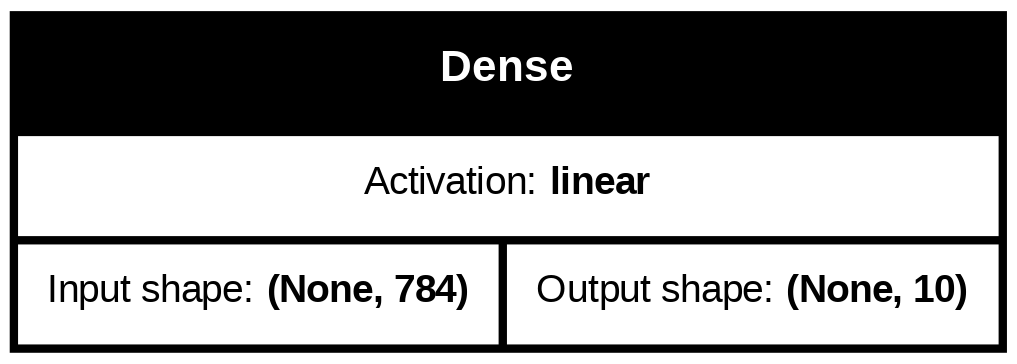

In [ ]:
model = linear_regression(x_train.shape[1], y_train.shape[1])  # Create model with 784 inputs and 10 outputs
model.summary()                                                # Show model structure
model.compile(optimizer=tf.keras.optimizers.Adam(),  loss="mse", metrics=["accuracy"])               # Specify optimizer (optional) and loss function
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True) # Graphical depiction of model

Training the model

Epoch 1/10
60/60 - 1s - 23ms/step - accuracy: 0.4564 - loss: 0.1179 - val_accuracy: 0.7043 - val_loss: 0.0691
Epoch 2/10
60/60 - 0s - 8ms/step - accuracy: 0.7520 - loss: 0.0607 - val_accuracy: 0.7974 - val_loss: 0.0538
Epoch 3/10
60/60 - 1s - 10ms/step - accuracy: 0.8032 - loss: 0.0513 - val_accuracy: 0.8261 - val_loss: 0.0484
Epoch 4/10
60/60 - 1s - 10ms/step - accuracy: 0.8216 - loss: 0.0472 - val_accuracy: 0.8347 - val_loss: 0.0456
Epoch 5/10
60/60 - 0s - 8ms/step - accuracy: 0.8296 - loss: 0.0450 - val_accuracy: 0.8444 - val_loss: 0.0439
Epoch 6/10
60/60 - 0s - 8ms/step - accuracy: 0.8367 - loss: 0.0435 - val_accuracy: 0.8468 - val_loss: 0.0427
Epoch 7/10
60/60 - 0s - 8ms/step - accuracy: 0.8395 - loss: 0.0425 - val_accuracy: 0.8466 - val_loss: 0.0419
Epoch 8/10
60/60 - 0s - 8ms/step - accuracy: 0.8428 - loss: 0.0417 - val_accuracy: 0.8516 - val_loss: 0.0412
Epoch 9/10
60/60 - 1s - 10ms/step - accuracy: 0.8454 - loss: 0.0411 - val_accuracy: 0.8529 - val_loss: 0.0409
Epoch 10/10
60/

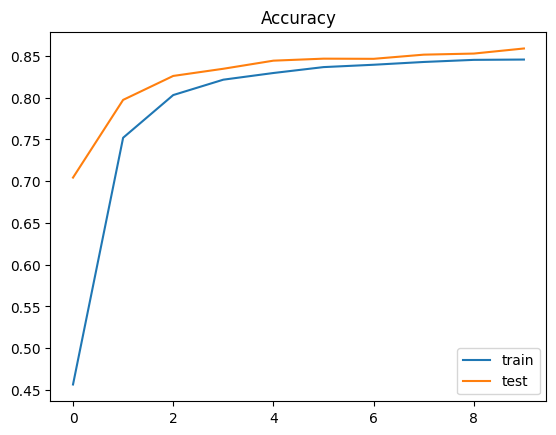

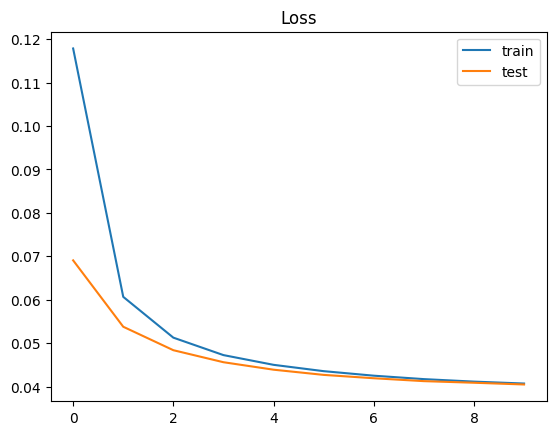

In [ ]:
start_train = time.time()
history = model.fit(
    x_train, y_train,
    epochs = 10,
    batch_size = 1000,
    verbose = 2, # Print loss and accuracy after evrey epoch. Set to 0 to see only final results
    validation_data=(x_test, y_test), # If provided, allows to keep track of loss on validation data as traiing progresses
)
end_train = time.time()
plot_results(history)
pred = model.predict(x_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:5.3f}'.format(mean_absolute_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(pred_int,np.argmax(y_test,axis=1))))
print('Confusion matrix')
print(confusion_matrix(np.argmax(y_test,axis=1), pred_int))


## **Logistic Regression**

In [ ]:
def logistic_regression(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Input((n_inputs,)))
  model.add(Dense(n_outputs))
  model.add(Softmax())
  return model

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                     │ (None, 10)                  │           7,850 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ softmax_4 (Softmax)                  │ (None, 10)                  │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

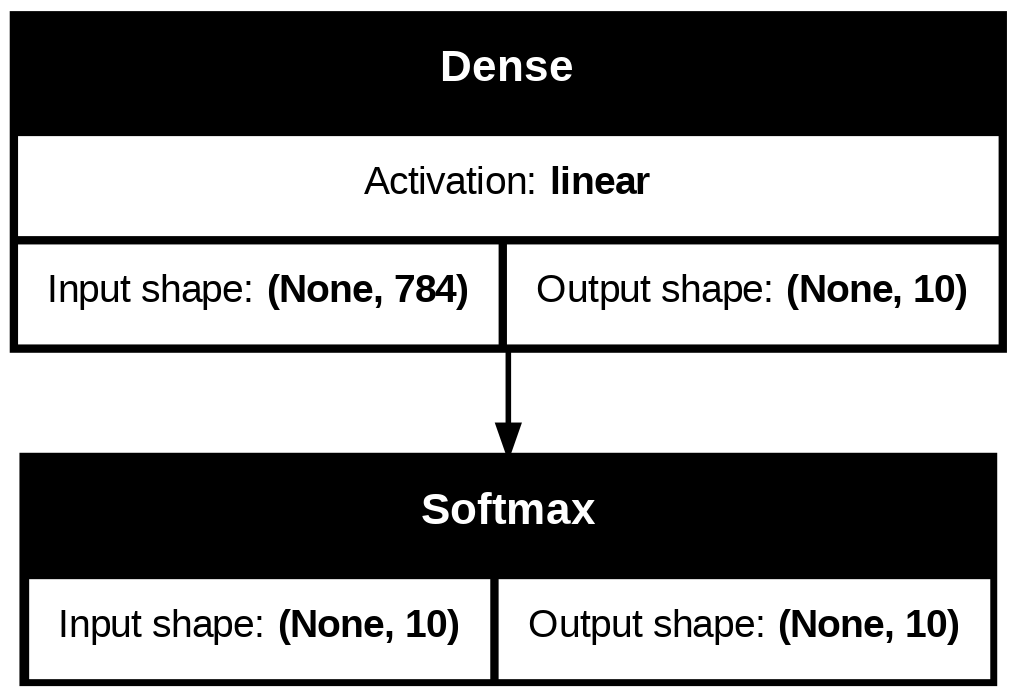

In [ ]:
model = logistic_regression(x_train.shape[1], y_train.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(),  loss="mse", metrics=["accuracy"])                # Specify optimizer (optional) and loss function
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

Epoch 1/40
60/60 - 2s - 38ms/step - accuracy: 0.6388 - loss: 0.0592 - val_accuracy: 0.8262 - val_loss: 0.0348
Epoch 2/40
60/60 - 2s - 38ms/step - accuracy: 0.8485 - loss: 0.0291 - val_accuracy: 0.8758 - val_loss: 0.0234
Epoch 3/40
60/60 - 1s - 20ms/step - accuracy: 0.8762 - loss: 0.0223 - val_accuracy: 0.8905 - val_loss: 0.0196
Epoch 4/40
60/60 - 1s - 13ms/step - accuracy: 0.8896 - loss: 0.0194 - val_accuracy: 0.8993 - val_loss: 0.0175
Epoch 5/40
60/60 - 1s - 9ms/step - accuracy: 0.8977 - loss: 0.0177 - val_accuracy: 0.9057 - val_loss: 0.0162
Epoch 6/40
60/60 - 0s - 8ms/step - accuracy: 0.9029 - loss: 0.0165 - val_accuracy: 0.9090 - val_loss: 0.0153
Epoch 7/40
60/60 - 1s - 10ms/step - accuracy: 0.9064 - loss: 0.0157 - val_accuracy: 0.9121 - val_loss: 0.0147
Epoch 8/40
60/60 - 1s - 11ms/step - accuracy: 0.9101 - loss: 0.0150 - val_accuracy: 0.9128 - val_loss: 0.0142
Epoch 9/40
60/60 - 0s - 8ms/step - accuracy: 0.9120 - loss: 0.0145 - val_accuracy: 0.9162 - val_loss: 0.0138
Epoch 10/40
6

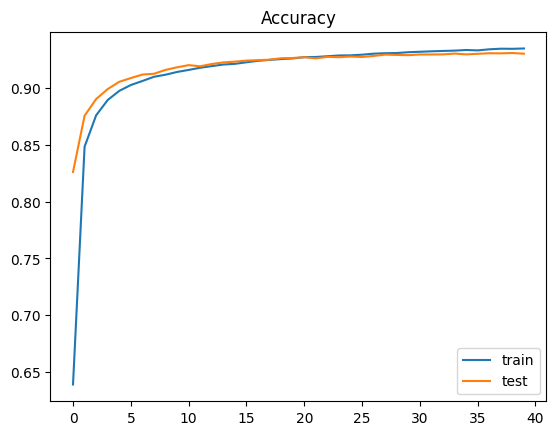

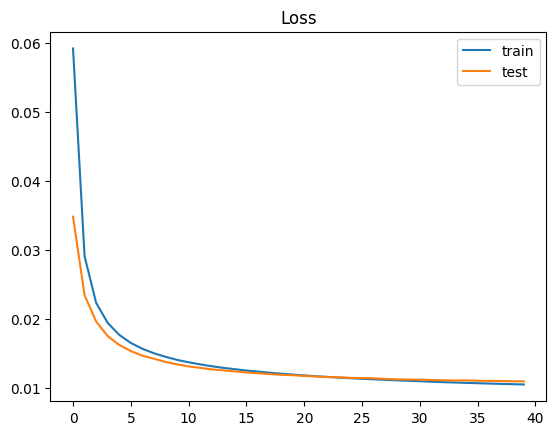

In [ ]:
start_train = time.time()
history = model.fit(
    x_train, y_train,
    epochs = 40,
    batch_size = 1000,
    verbose = 2, # Print loss and accuracy after evrey epoch. Set to 0 to see only final results
    validation_data=(x_test, y_test), # If provided, allows to keep track of loss on validation data as traiing progresses
)
end_train = time.time()
plot_results(history)
pred = model.predict(x_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:5.3f}'.format(mean_absolute_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(pred_int,np.argmax(y_test,axis=1))))
print('Confusion matrix')
print(confusion_matrix(np.argmax(y_test,axis=1), pred_int))

Replacing the loss function

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                     │ (None, 10)                  │           7,850 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ softmax_5 (Softmax)                  │ (None, 10)                  │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

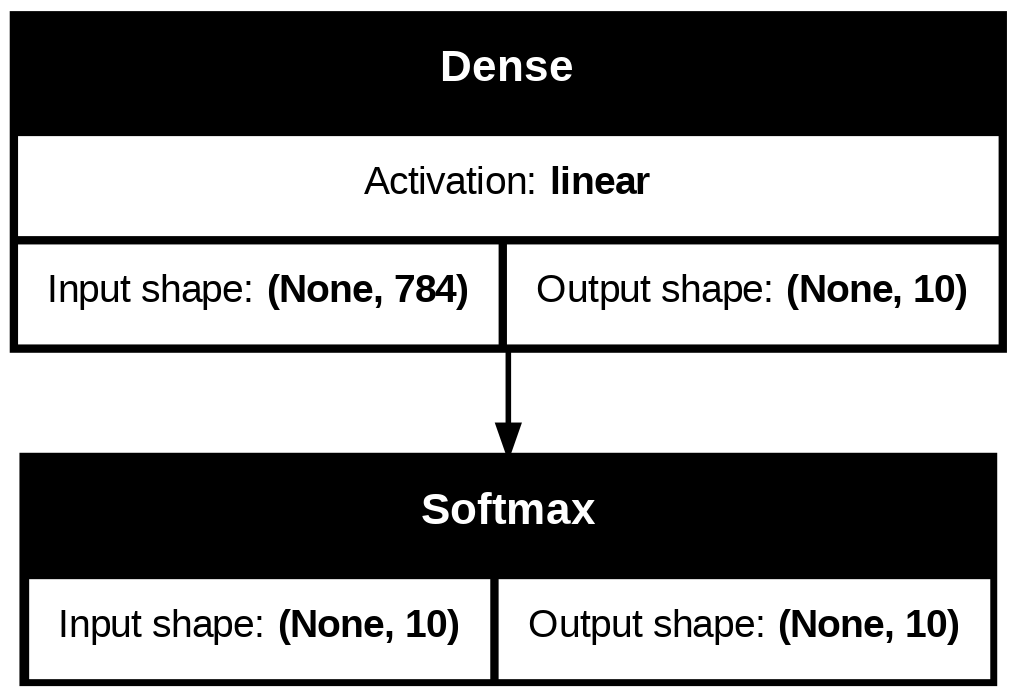

In [ ]:
model = logistic_regression(x_train.shape[1], y_train.shape[1])
model.summary()
opt = tf.keras.optimizers.Adam()
model.compile(optimizer=opt, loss="CategoricalCrossentropy", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

### Quadratic Feature Expansion

In [ ]:
# Keep the original 784-feature MNIST arrays unchanged.
x_train_quad = np.hstack((x_train, x_train**2))
x_test_quad = np.hstack((x_test, x_test**2))

print("Original feature count:", x_train.shape[1])
print("Quadratic feature count:", x_train_quad.shape[1])

In [ ]:
def linear_regression(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Input((n_inputs,)))
  model.add(Dense(n_outputs))
  return model

In [ ]:
model = linear_regression(x_train_quad.shape[1], y_train.shape[1])
model.summary()
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="mse",
    metrics=["accuracy"]
)
plot_model(
    model,
    show_shapes=True,
    show_layer_names=False,
    show_layer_activations=True
)

In [ ]:
start_train = time.time()
history = model.fit(
    x_train_quad, y_train,
    epochs = 10,
    batch_size = 1000,
    verbose = 2, # Print loss and accuracy after evrey epoch. Set to 0 to see only final results
    validation_data=(x_test_quad, y_test), # If provided, allows to keep track of loss on validation data as traiing progresses
)
end_train = time.time()

In [ ]:
plot_results(history)
pred = model.predict(x_test_quad)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:5.3f}'.format(mean_absolute_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(pred_int,np.argmax(y_test,axis=1))))
print('Confusion matrix')
print(confusion_matrix(np.argmax(y_test,axis=1), pred_int))

In [ ]:
model = logistic_regression(x_train_quad.shape[1], y_train.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(),  loss="CategoricalCrossentropy", metrics=["accuracy"])                # Specify optimizer (optional) and loss function
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

In [ ]:
start_train = time.time()
history = model.fit(
    x_train_quad, y_train,
    epochs = 40,
    batch_size = 1000,
    verbose = 2, # Print loss and accuracy after evrey epoch. Set to 0 to see only final results
    validation_data=(x_test_quad, y_test), # If provided, allows to keep track of loss on validation data as traiing progresses
)
end_train = time.time()

In [ ]:
plot_results(history)
pred = model.predict(x_test_quad)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:5.3f}'.format(mean_absolute_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(
    accuracy_score(pred_int,np.argmax(y_test,axis=1))
))
print('Confusion matrix')
print(confusion_matrix(np.argmax(y_test,axis=1), pred_int))

### Additional Dense Layer in the Linear Model

In [ ]:
def linear_regression(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Input((n_inputs,)))
  model.add(Dense(n_outputs)) # another layer
  model.add(Dense(n_outputs))
  return model

In [ ]:
model = linear_regression(x_train_quad.shape[1], y_train.shape[1])
model.summary()
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="mse",
    metrics=["accuracy"]
)
plot_model(
    model,
    show_shapes=True,
    show_layer_names=False,
    show_layer_activations=True
)

In [ ]:
start_train = time.time()
history = model.fit(
    x_train_quad, y_train,
    epochs=10,
    batch_size=1000,
    verbose=2,
    validation_data=(x_test_quad, y_test),
)
end_train = time.time()

In [ ]:
plot_results(history)
pred = model.predict(x_test_quad)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:5.3f}'.format(mean_absolute_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(
    accuracy_score(pred_int,np.argmax(y_test,axis=1))
))
print('Confusion matrix')
print(confusion_matrix(np.argmax(y_test,axis=1), pred_int))

### Additional Dense and Softmax Layers

In [ ]:
def logistic_regression(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Input((n_inputs,)))
  model.add(Dense(n_outputs)) # another layer
  model.add(Dense(n_outputs))
  model.add(Softmax())
  return model

In [ ]:
model = logistic_regression(x_train_quad.shape[1], y_train.shape[1])
model.summary()
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="CategoricalCrossentropy",
    metrics=["accuracy"]
)
plot_model(
    model,
    show_shapes=True,
    show_layer_names=False,
    show_layer_activations=True
)

In [ ]:
start_train = time.time()
history = model.fit(
    x_train_quad, y_train,
    epochs=40,
    batch_size=1000,
    verbose=2,
    validation_data=(x_test_quad, y_test),
)
end_train = time.time()

In [ ]:
plot_results(history)
pred = model.predict(x_test_quad)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:5.3f}'.format(mean_absolute_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(
    accuracy_score(pred_int,np.argmax(y_test,axis=1))
))
print('Confusion matrix')
print(confusion_matrix(np.argmax(y_test,axis=1), pred_int))

In [ ]:
x_train_quad.shape

## Two-Layer Linear and Nonlinear Networks

These experiments test whether adding another layer and changing activation/loss choices improves classification.

### MNIST Input Preparation

This architecture study uses the original flattened 28 × 28 MNIST input, giving 784 features per image.

In [ ]:
# Prepare the original 784-feature MNIST representation for this architecture study.
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = np.float32(x_train / 255).reshape(x_train.shape[0], -1)
x_test = np.float32(x_test / 255).reshape(x_test.shape[0], -1)

y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

print("Training input shape:", x_train.shape)
print("Test input shape:", x_test.shape)

### Specified Dense-Network Configuration

A 500-unit ReLU hidden layer is specified with stochastic gradient descent, learning rate 0.1, momentum 0.95, 30 epochs, and batch size 50, together with overall and class-level evaluation. The implementation sequence that follows uses the MNIST dataset loader present in the code.

In [ ]:
def plot_results(history):
  fig, ax = plt.subplots(ncols=2, figsize=(12,4))
  ax[0].plot(history.history['accuracy'],label = 'train')
  ax[0].plot(history.history['val_accuracy'],label = 'test')
  ax[0].set_title('Accuracy')
  ax[0].legend(loc='lower right')
  ax[1].plot(history.history['loss'],label = 'train')
  ax[1].plot(history.history['val_loss'],label = 'test')
  ax[1].set_title('Loss')
  ax[1].legend(loc='upper right')

## **Linear Regression with two layers**

In [ ]:
def linear_regression(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Dense(500, input_shape=(n_inputs,))) # A Dense layer implements the function y = Wx + b
  model.add(Dense(n_outputs)) # A Dense layer implements the function y = Wx + b
  return model

In [ ]:
plot_results(history)
pred = model.predict(x_test_quad)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:5.3f}'.format(mean_absolute_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(
    accuracy_score(pred_int,np.argmax(y_test,axis=1))
))
print('Confusion matrix')
print(confusion_matrix(np.argmax(y_test,axis=1), pred_int))

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 500)               392500    
                                                                 
 dense_1 (Dense)             (None, 10)                5010      
                                                                 
Total params: 397510 (1.52 MB)
Trainable params: 397510 (1.52 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


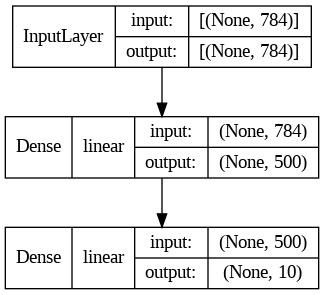

In [ ]:
model = linear_regression(x_train.shape[1], y_train.shape[1])  # Create model with 784 inputs and 10 outputs
model.summary()                                                # Show model structure
opt = tf.keras.optimizers.SGD(learning_rate=0.01,momentum=0.9)
model.compile(optimizer=opt, loss="mse", metrics=["accuracy"]) # Specify optimizer and loss function
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True) # Graphical depiction of model

Epoch 1/40
600/600 - 6s - loss: 0.0570 - accuracy: 0.7792 - val_loss: 0.0444 - val_accuracy: 0.8412 - 6s/epoch - 10ms/step
Epoch 2/40
600/600 - 1s - loss: 0.0433 - accuracy: 0.8388 - val_loss: 0.0414 - val_accuracy: 0.8480 - 1s/epoch - 2ms/step
Epoch 3/40
600/600 - 1s - loss: 0.0415 - accuracy: 0.8447 - val_loss: 0.0409 - val_accuracy: 0.8562 - 1s/epoch - 2ms/step
Epoch 4/40
600/600 - 1s - loss: 0.0407 - accuracy: 0.8473 - val_loss: 0.0399 - val_accuracy: 0.8565 - 1s/epoch - 2ms/step
Epoch 5/40
600/600 - 1s - loss: 0.0403 - accuracy: 0.8483 - val_loss: 0.0397 - val_accuracy: 0.8552 - 1s/epoch - 2ms/step
Epoch 6/40
600/600 - 1s - loss: 0.0400 - accuracy: 0.8501 - val_loss: 0.0395 - val_accuracy: 0.8607 - 1s/epoch - 2ms/step
Epoch 7/40
600/600 - 1s - loss: 0.0398 - accuracy: 0.8508 - val_loss: 0.0393 - val_accuracy: 0.8602 - 1s/epoch - 2ms/step
Epoch 8/40
600/600 - 1s - loss: 0.0396 - accuracy: 0.8501 - val_loss: 0.0391 - val_accuracy: 0.8525 - 1s/epoch - 2ms/step
Epoch 9/40
600/600 - 1s

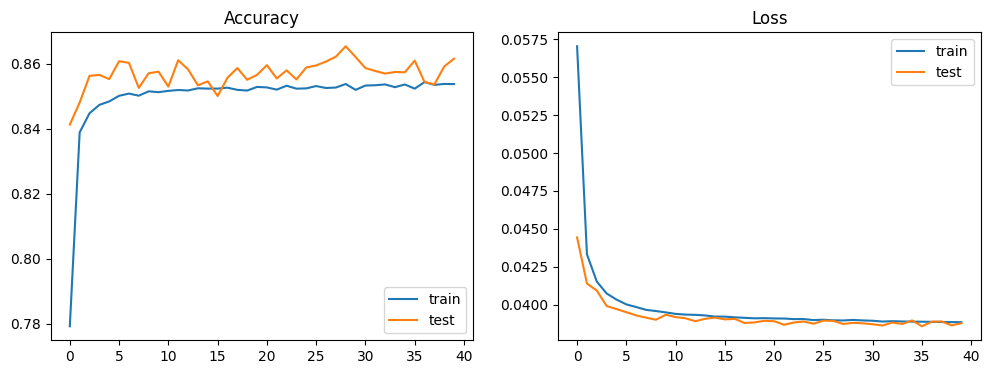

In [ ]:
start_train = time.time()
history = model.fit(
    x_train, y_train,
    epochs = 40,
    batch_size = 100,
    verbose = 2, # Print loss and accuracy after evrey epoch. Set to 0 to see only final results
    validation_data=(x_test, y_test), # If provided, allows to keep track of loss on validation data as traiing progresses
)
end_train = time.time()
plot_results(history)
pred = model.predict(x_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:5.3f}'.format(mean_absolute_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(pred_int,np.argmax(y_test,axis=1))))
print('Confusion matrix')
print(confusion_matrix(np.argmax(y_test,axis=1), pred_int))


## **Logistic Regression with two layers**

In [ ]:
def logistic_regression(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Dense(500, input_shape=(n_inputs,), activation='sigmoid'))
  model.add(Dense(n_outputs, activation='softmax'))
  return model

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 500)               392500    
                                                                 
 dense_3 (Dense)             (None, 10)                5010      
                                                                 
Total params: 397510 (1.52 MB)
Trainable params: 397510 (1.52 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


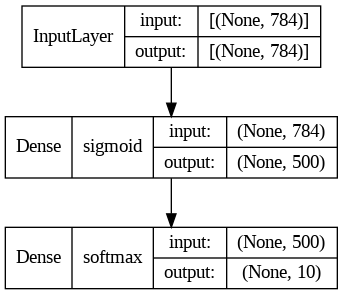

In [ ]:
model = logistic_regression(x_train.shape[1], y_train.shape[1])
model.summary()
opt = tf.keras.optimizers.SGD(learning_rate=0.2,momentum=0.9)
model.compile(optimizer=opt, loss="mse", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

Epoch 1/40
600/600 - 2s - loss: 0.0416 - accuracy: 0.7362 - val_loss: 0.0201 - val_accuracy: 0.8791 - 2s/epoch - 3ms/step
Epoch 2/40
600/600 - 1s - loss: 0.0179 - accuracy: 0.8897 - val_loss: 0.0153 - val_accuracy: 0.9041 - 1s/epoch - 2ms/step
Epoch 3/40
600/600 - 1s - loss: 0.0153 - accuracy: 0.9027 - val_loss: 0.0138 - val_accuracy: 0.9128 - 1s/epoch - 2ms/step
Epoch 4/40
600/600 - 1s - loss: 0.0142 - accuracy: 0.9084 - val_loss: 0.0129 - val_accuracy: 0.9153 - 1s/epoch - 2ms/step
Epoch 5/40
600/600 - 1s - loss: 0.0135 - accuracy: 0.9131 - val_loss: 0.0125 - val_accuracy: 0.9187 - 1s/epoch - 2ms/step
Epoch 6/40
600/600 - 1s - loss: 0.0130 - accuracy: 0.9168 - val_loss: 0.0121 - val_accuracy: 0.9219 - 1s/epoch - 2ms/step
Epoch 7/40
600/600 - 1s - loss: 0.0126 - accuracy: 0.9184 - val_loss: 0.0122 - val_accuracy: 0.9202 - 1s/epoch - 2ms/step
Epoch 8/40
600/600 - 1s - loss: 0.0122 - accuracy: 0.9211 - val_loss: 0.0117 - val_accuracy: 0.9248 - 1s/epoch - 2ms/step
Epoch 9/40
600/600 - 1s 

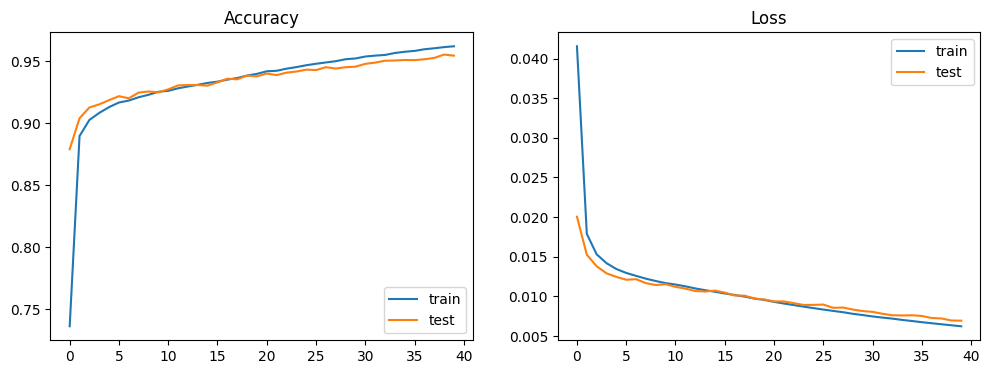

In [ ]:
start_train = time.time()
history = model.fit(
    x_train, y_train,
    epochs = 40,
    batch_size = 100,
    verbose = 2,
    validation_data=(x_test, y_test),
)
end_train = time.time()
plot_results(history)
pred = model.predict(x_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:5.3f}'.format(mean_absolute_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(pred_int,np.argmax(y_test,axis=1))))
print('Confusion matrix')
print(confusion_matrix(np.argmax(y_test,axis=1), pred_int))

### **Using cross-entropy loss.** Replacing the loss function by categorical cross entropy, where $y_{i,c} = 1 $ if example $i$ belongs to class $c$ and $y_{i,c} = 0 $ otherwise and  $p_{i,c}  $ is the corresponding prediction made by the network.

$$c(y_i,p_i) = -\sum_{c=1}^My_{i,c}\log(p_{i,c})$$

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 500)               392500    
                                                                 
 dense_5 (Dense)             (None, 10)                5010      
                                                                 
Total params: 397510 (1.52 MB)
Trainable params: 397510 (1.52 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


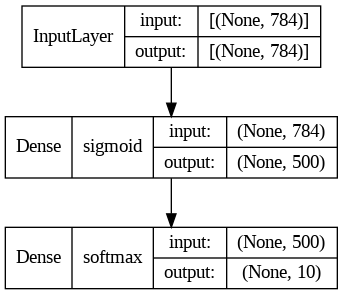

In [ ]:
model = logistic_regression(x_train.shape[1], y_train.shape[1])
model.summary()
opt = tf.keras.optimizers.SGD(learning_rate=0.2,momentum=0.9)
model.compile(optimizer=opt, loss="CategoricalCrossentropy", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

Epoch 1/40
600/600 - 2s - loss: 0.4428 - accuracy: 0.8801 - val_loss: 0.1860 - val_accuracy: 0.9419 - 2s/epoch - 3ms/step
Epoch 2/40
600/600 - 1s - loss: 0.1484 - accuracy: 0.9563 - val_loss: 0.1226 - val_accuracy: 0.9639 - 1s/epoch - 2ms/step
Epoch 3/40
600/600 - 1s - loss: 0.1051 - accuracy: 0.9692 - val_loss: 0.0976 - val_accuracy: 0.9700 - 1s/epoch - 2ms/step
Epoch 4/40
600/600 - 1s - loss: 0.0810 - accuracy: 0.9759 - val_loss: 0.0897 - val_accuracy: 0.9720 - 1s/epoch - 2ms/step
Epoch 5/40
600/600 - 1s - loss: 0.0659 - accuracy: 0.9804 - val_loss: 0.0790 - val_accuracy: 0.9752 - 1s/epoch - 2ms/step
Epoch 6/40
600/600 - 1s - loss: 0.0546 - accuracy: 0.9835 - val_loss: 0.0708 - val_accuracy: 0.9788 - 1s/epoch - 2ms/step
Epoch 7/40
600/600 - 1s - loss: 0.0454 - accuracy: 0.9871 - val_loss: 0.0803 - val_accuracy: 0.9758 - 1s/epoch - 2ms/step
Epoch 8/40
600/600 - 1s - loss: 0.0386 - accuracy: 0.9891 - val_loss: 0.0726 - val_accuracy: 0.9772 - 1s/epoch - 2ms/step
Epoch 9/40
600/600 - 1s 

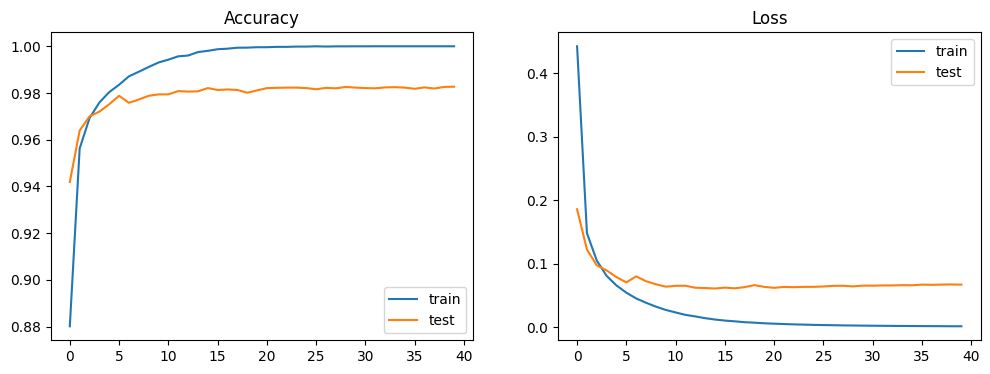

In [ ]:
start_train = time.time()
history = model.fit(
    x_train, y_train,
    epochs = 40,
    batch_size = 100,
    verbose = 2,
    validation_data=(x_test, y_test),
)
end_train = time.time()
plot_results(history)
pred = model.predict(x_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(pred_int,np.argmax(y_test,axis=1))))
print('Confusion matrix')
print(confusion_matrix(np.argmax(y_test,axis=1), pred_int))


### **Using ReLU activation function**

Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_18 (Dense)            (None, 500)               392500    
                                                                 
 dense_19 (Dense)            (None, 10)                5010      
                                                                 
Total params: 397510 (1.52 MB)
Trainable params: 397510 (1.52 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


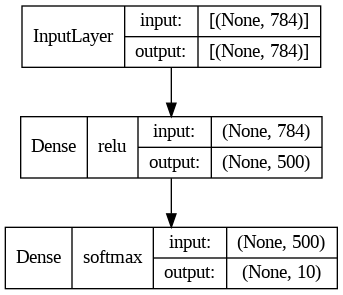

In [ ]:
def logistic_regression(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Dense(500, input_shape=(n_inputs,), activation='relu'))
  model.add(Dense(n_outputs, activation='softmax'))
  return model

model = logistic_regression(x_train.shape[1], y_train.shape[1])
model.summary()
opt = tf.keras.optimizers.SGD(learning_rate=0.2,momentum=0.9)
model.compile(optimizer=opt, loss="CategoricalCrossentropy", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

In [ ]:
start_train = time.time()
history = model.fit(
    x_train, y_train,
    epochs=40,
    batch_size=100,
    verbose=2,
    validation_data=(x_test, y_test),
)
end_train = time.time()

plot_results(history)
pred = model.predict(x_test)

print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
pred_int = np.argmax(pred, axis=1)
print('Accuracy = {:.4f}'.format(
    accuracy_score(pred_int, np.argmax(y_test, axis=1))
))
print('Confusion matrix')
print(confusion_matrix(np.argmax(y_test, axis=1), pred_int))

## One- and Two-Hidden-Layer MNIST Models

MNIST classification is extended from linear and logistic baselines to dense networks with one and two hidden layers. Distinct implementation variants and evaluations are retained.

## MNIST Classification Study

The following TensorFlow experiments train and evaluate multiple classification approaches on MNIST. Model assessment includes training and test accuracy together with test-set confusion matrices.

### Data Loading and Preprocessing

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.activations import *
from keras.utils import plot_model
from sklearn.metrics import accuracy_score, confusion_matrix,mean_squared_error,mean_absolute_error
import time

In [ ]:
def plot_results(history):
  fig, ax = plt.subplots(ncols=2, figsize=(12,4))
  ax[0].plot(history.history['accuracy'],label = 'train')
  ax[0].plot(history.history['val_accuracy'],label = 'test')
  ax[0].set_title('Accuracy')
  ax[0].legend(loc='lower right')
  ax[0].grid(True)
  ax[1].plot(history.history['loss'],label = 'train')
  ax[1].plot(history.history['val_loss'],label = 'test')
  ax[1].set_title('Loss')
  ax[1].legend(loc='upper right')
  ax[1].grid(True)

In [ ]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print(f'{X_train.shape=}')
print(f'{X_test.shape=}')
print(f'{y_train.shape=}')
print(f'{y_test.shape=}')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
X_train.shape=(60000, 28, 28)
X_test.shape=(10000, 28, 28)
y_train.shape=(60000,)
y_test.shape=(10000,)


Class: 9


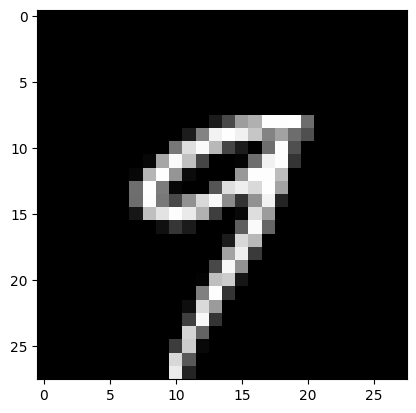

000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 027 073 157 176 254 254 255 109 000 000 000 

In [ ]:
im = np.random.randint(0,X_train.shape[0])
plt.imshow(X_train[im],cmap='gray')
print('Class:',y_train[im])
plt.show()

for i in range(28):
    for j in range(28):
        print(str(np.int16(X_train[im,i,j])+1000)[1:],end=' ')
    print()

### Additional MNIST Examples

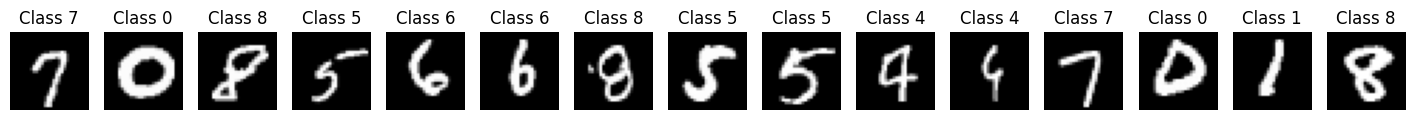

In [ ]:
nimgs = 15
sel = np.random.randint(0,X_train.shape[0],size =nimgs)
fig, ax = plt.subplots(ncols=nimgs, figsize=(18,4))
for i, s in enumerate(sel):
  ax[i].imshow(X_train[s],cmap='gray')
  ax[i].set_title(f'Class {y_train[s]}')
  ax[i].set_axis_off()
plt.show()

## Pre-processing

We convert the 3D train and test datasets to 2D arrays by concatenating all pixel values in an image to a single row. We also convert to floating point. We convert the class to a one_hot representation (i.e. 1 becomes [0,1,0,0,0,0,0,0,0,0]).

In [ ]:
X_train = np.float32(X_train.reshape(X_train.shape[0],-1))/255
X_test = np.float32(X_test.reshape(X_test.shape[0],-1))/255
y_train_oh = tf.keras.utils.to_categorical(y_train, 10)
y_test_oh = tf.keras.utils.to_categorical(y_test, 10)
print(f'{X_train.shape=}')
print(f'{X_test.shape=}')
print(f'{y_train.shape=}')
print(f'{y_test.shape=}')
print(f'{y_train_oh.shape=}')
print(f'{y_test_oh.shape=}')


X_train.shape=(60000, 784)
X_test.shape=(10000, 784)
y_train.shape=(60000,)
y_test.shape=(10000,)
y_train_oh.shape=(60000, 10)
y_test_oh.shape=(10000, 10)


## Linear Classification Baseline

**Creating the model**

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

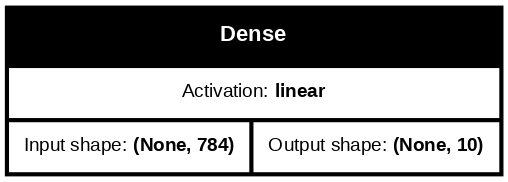

In [ ]:
def linear_regression(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Input((n_inputs,)))
  model.add(Dense(n_outputs))
  return model

model = linear_regression(X_train.shape[1], y_train_oh.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss="mse", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True,rankdir='LR',dpi=100)

**Training the model**

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Elapsed time training= 5.3008 secs
Accuracy = 0.8472


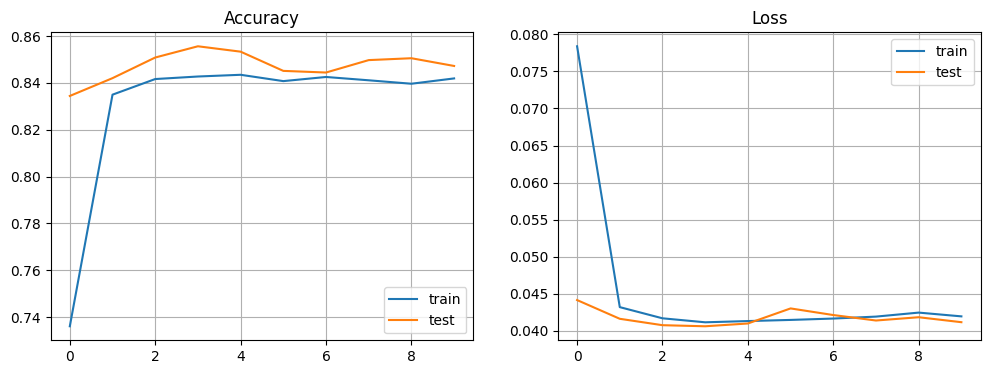

In [ ]:
start_train = time.time()
history = model.fit(
    X_train, y_train_oh,
    epochs = 10,
    batch_size = 500,
    verbose = 0,
    validation_data=(X_test, y_test_oh),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(y_test,np.argmax(pred,axis=1))))

In [ ]:
print(np.argmax(history.history['val_accuracy']))
print(np.argmin(history.history['val_loss']))
print(np.argmax(history.history['accuracy']))
print(np.argmin(history.history['loss']))

3
3
4
3


## Logistic Classification Baseline

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

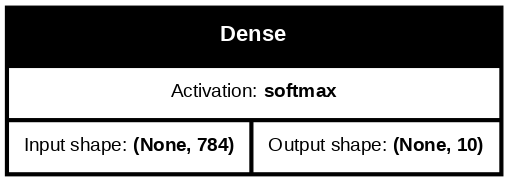

In [ ]:
def logistic_regression(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Input((n_inputs,)))
  model.add(Dense(n_outputs,activation='softmax'))
  return model

model = logistic_regression(X_train.shape[1], y_train_oh.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss="categorical_crossentropy", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True,rankdir='LR',dpi=100)

Epoch 1/10
120/120 - 2s - 13ms/step - accuracy: 0.8687 - loss: 0.4564 - val_accuracy: 0.9169 - val_loss: 0.2972
Epoch 2/10
120/120 - 0s - 3ms/step - accuracy: 0.9178 - loss: 0.2949 - val_accuracy: 0.9224 - val_loss: 0.2801
Epoch 3/10
120/120 - 0s - 3ms/step - accuracy: 0.9222 - loss: 0.2789 - val_accuracy: 0.9239 - val_loss: 0.2778
Epoch 4/10
120/120 - 0s - 3ms/step - accuracy: 0.9247 - loss: 0.2701 - val_accuracy: 0.9239 - val_loss: 0.2728
Epoch 5/10
120/120 - 0s - 3ms/step - accuracy: 0.9263 - loss: 0.2640 - val_accuracy: 0.9252 - val_loss: 0.2699
Epoch 6/10
120/120 - 0s - 3ms/step - accuracy: 0.9277 - loss: 0.2592 - val_accuracy: 0.9243 - val_loss: 0.2716
Epoch 7/10
120/120 - 0s - 3ms/step - accuracy: 0.9291 - loss: 0.2558 - val_accuracy: 0.9257 - val_loss: 0.2683
Epoch 8/10
120/120 - 0s - 3ms/step - accuracy: 0.9300 - loss: 0.2535 - val_accuracy: 0.9248 - val_loss: 0.2708
Epoch 9/10
120/120 - 0s - 3ms/step - accuracy: 0.9305 - loss: 0.2509 - val_accuracy: 0.9194 - val_loss: 0.2789


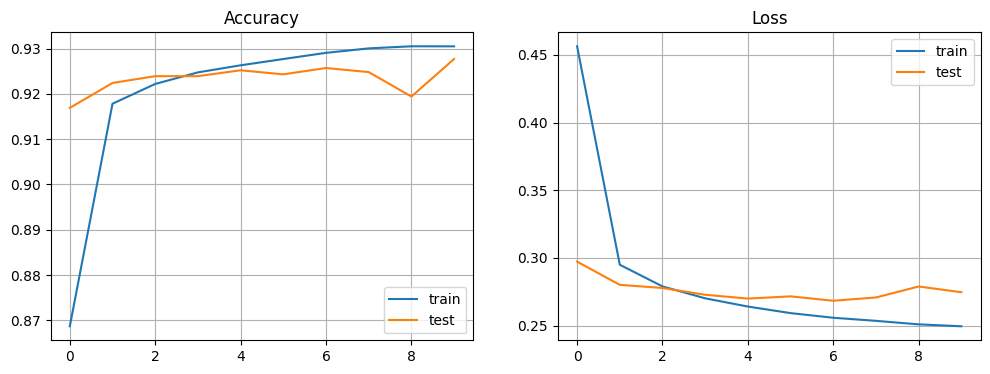

In [ ]:
start_train = time.time()
history = model.fit(
    X_train, y_train_oh,
    epochs = 10,
    batch_size = 500,
    verbose = 2,
    validation_data=(X_test, y_test_oh),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(y_test,np.argmax(pred,axis=1))))

## Dense Network with One Hidden Layer

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 397,510 (1.52 MB)

 Trainable params: 397,510 (1.52 MB)

 Non-trainable params: 0 (0.00 B)

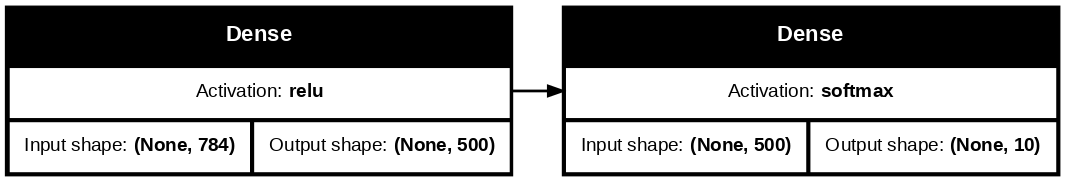

In [ ]:
def ffnn_one_HL(n_inputs, hidden, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Input((n_inputs,)))
  model.add(Dense(hidden,activation='relu'))
  model.add(Dense(n_outputs,activation='softmax'))
  return model

model = ffnn_one_HL(X_train.shape[1], 500,y_train_oh.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss="categorical_crossentropy", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True,rankdir='LR',dpi=100)

**Training and evaluation**

In [ ]:
start_train = time.time()
history = model.fit(
    X_train, y_train_oh,
    epochs=10,
    batch_size=500,
    verbose=2,
    validation_data=(X_test, y_test_oh),
)
end_train = time.time()

plot_results(history)
pred = model.predict(X_test)

print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
pred_int = np.argmax(pred, axis=1)
print('Accuracy = {:.4f}'.format(
    accuracy_score(y_test, np.argmax(pred, axis=1))
))

## Dense Network with Two Hidden Layers

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 500)            │       250,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,010 (2.47 MB)

 Trainable params: 648,010 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

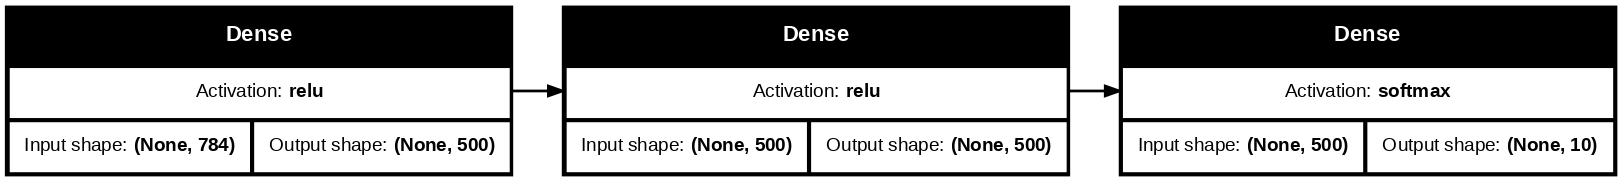

In [ ]:
def ffnn_two_HL(n_inputs, hidden1, hidden2, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Input((n_inputs,)))
  model.add(Dense(hidden1,activation='relu'))
  model.add(Dense(hidden2,activation='relu'))
  model.add(Dense(n_outputs,activation='softmax'))
  return model

model = ffnn_two_HL(X_train.shape[1], 500, 500, y_train_oh.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss="categorical_crossentropy",  metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True,rankdir='LR',dpi=100)

**Training and evaluation**

In [ ]:
start_train = time.time()
history = model.fit(
    X_train, y_train_oh,
    epochs=10,
    batch_size=500,
    verbose=2,
    validation_data=(X_test, y_test_oh),
)
end_train = time.time()

plot_results(history)
pred = model.predict(X_test)

print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
pred_int = np.argmax(pred, axis=1)
print('Accuracy = {:.4f}'.format(
    accuracy_score(y_test, np.argmax(pred, axis=1))
))

# Some considerations for building and training neural networks

**The network's architecture**
*   Number, type and size of every layer. Networks with more parameters tend to overfit, networks with fewer parameters tend to underfit.
*   Activation functions - *relu* works well for hidden layers, *softmax* for output in multiclass classification, *sigmoid* for binary classification
*   Loss functions - *MSE* for regression, *categorical cross entropy* for multiclass classification, *binary cross entropy* for binary classification

**The training process**
*   Choice of optimizer - *Adam* works well for most problems
*   Learning rate - start with default value, try increasing and decreasing by a factor of 10
*   Batch size - smaller batches usually result in better accuracy for the same number of epochs, larger batches usually result in shorter running times for the same number of epochs.
*   Training for more epochs may lead to overfitting, training for fewer epochs may lead to underfitting

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

In [ ]:
print(f'{X_train.shape=}')
print(f'{X_test.shape=}')
print(f'{y_train.shape=}')
print(f'{y_test.shape=}')

X_train.shape=(60000, 28, 28)
X_test.shape=(10000, 28, 28)
y_train.shape=(60000,)
y_test.shape=(10000,)


Class: 4


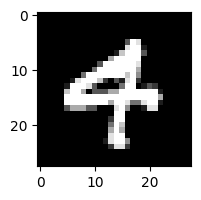

Class: 6


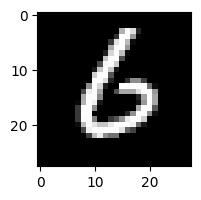

Class: 3


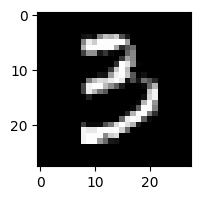

Class: 8


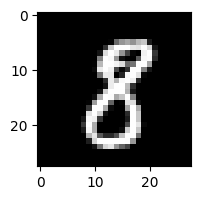

Class: 4


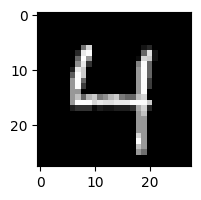

In [ ]:
for i in range(5):
  im = np.random.randint(0,X_train.shape[0])
  plt.figure(figsize=(2,2))
  plt.imshow(X_train[im],cmap='gray')
  print('Class:',y_train[im])
  plt.show()

We convert the 3D train and test datasets to 2D arrays by concatenating all pixels values in an image to a single row. We also convert to floating point. We convert the class to a one_hot representation (i.e. 1 becomes [0,1,0,0,0,0,0,0,0,0]).

In [ ]:
X_train = np.float32(X_train.reshape(X_train.shape[0],-1))/255
X_test = np.float32(X_test.reshape(X_test.shape[0],-1))/255
y_train_oh = tf.keras.utils.to_categorical(y_train, 10)
y_test_oh = tf.keras.utils.to_categorical(y_test, 10)
print(f'{X_train.shape=}')
print(f'{X_test.shape=}')
print(f'{y_train.shape=}')
print(f'{y_test.shape=}')
print(f'{y_train_oh.shape=}')
print(f'{y_test_oh.shape=}')

y_train_oh = tf.keras.utils.to_categorical(y_train, 10)
y_test_oh = tf.keras.utils.to_categorical(y_test, 10)

X_train.shape=(60000, 784)
X_test.shape=(10000, 784)
y_train.shape=(60000,)
y_test.shape=(10000,)
y_train_oh.shape=(60000, 10)
y_test_oh.shape=(10000, 10)


In [ ]:
import os
import distutils
from keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.activations import *
from keras.utils import plot_model
from sklearn.metrics import accuracy_score, confusion_matrix,mean_squared_error,mean_absolute_error
import time

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

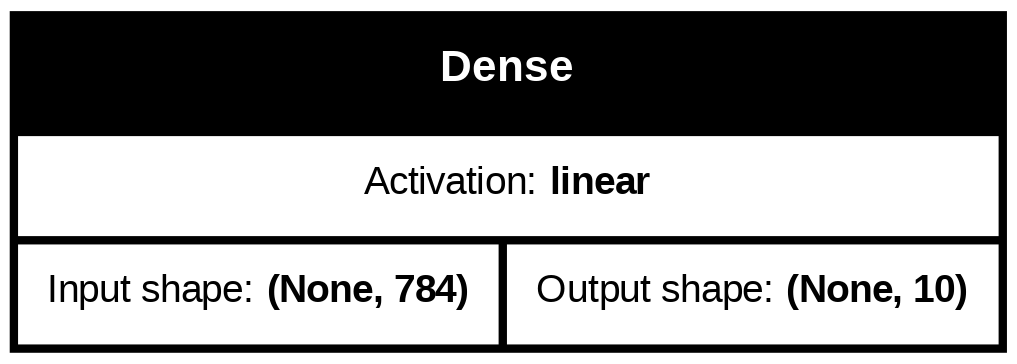

In [ ]:
model = linear_regression(X_train.shape[1], y_train_oh.shape[1])  # Create model with 784 inputs and 10 outputs
model.summary()                                                # Show model structure
model.compile(optimizer=tf.keras.optimizers.Adam(),  loss="mse", metrics=["accuracy"])               # Specify optimizer (optional) and loss function
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True) # Graphical depiction of model

Epoch 1/10
60/60 - 1s - 23ms/step - accuracy: 0.4725 - loss: 0.1148 - val_accuracy: 0.7128 - val_loss: 0.0671
Epoch 2/10
60/60 - 1s - 9ms/step - accuracy: 0.7540 - loss: 0.0591 - val_accuracy: 0.7992 - val_loss: 0.0522
Epoch 3/10
60/60 - 1s - 11ms/step - accuracy: 0.8030 - loss: 0.0501 - val_accuracy: 0.8185 - val_loss: 0.0474
Epoch 4/10
60/60 - 0s - 7ms/step - accuracy: 0.8200 - loss: 0.0464 - val_accuracy: 0.8340 - val_loss: 0.0447
Epoch 5/10
60/60 - 1s - 10ms/step - accuracy: 0.8301 - loss: 0.0443 - val_accuracy: 0.8427 - val_loss: 0.0431
Epoch 6/10
60/60 - 1s - 10ms/step - accuracy: 0.8364 - loss: 0.0429 - val_accuracy: 0.8450 - val_loss: 0.0420
Epoch 7/10
60/60 - 1s - 11ms/step - accuracy: 0.8389 - loss: 0.0420 - val_accuracy: 0.8466 - val_loss: 0.0413
Epoch 8/10
60/60 - 1s - 24ms/step - accuracy: 0.8420 - loss: 0.0413 - val_accuracy: 0.8536 - val_loss: 0.0409
Epoch 9/10
60/60 - 1s - 15ms/step - accuracy: 0.8453 - loss: 0.0408 - val_accuracy: 0.8541 - val_loss: 0.0405
Epoch 10/10


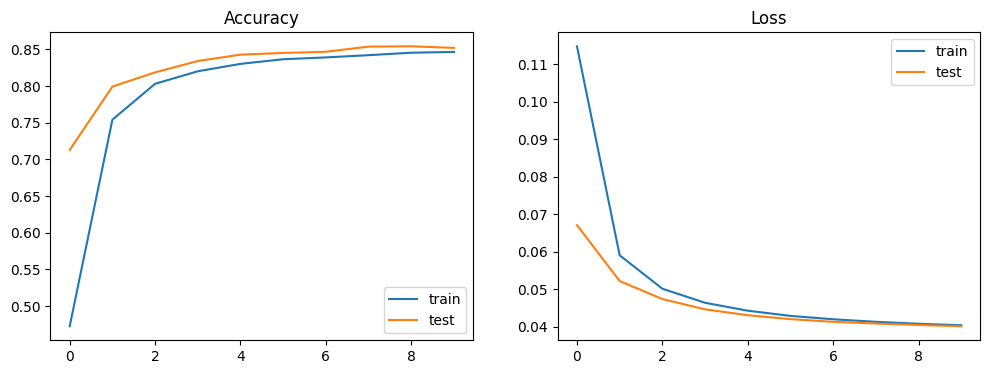

In [ ]:
start_train = time.time()
history = model.fit(
    X_train, y_train_oh,
    epochs = 10,
    batch_size = 1000,
    verbose = 2, # Print loss and accuracy after evrey epoch. Set to 0 to see only final results
    validation_data=(X_test, y_test_oh), # If provided, allows to keep track of loss on validation data as traiing progresses
)
end_train = time.time()
plot_results(history)

pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test_oh)))
print('Mean absolute error =  {:5.3f}'.format(mean_absolute_error(pred,y_test_oh)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(pred_int,np.argmax(y_test_oh,axis=1))))
print('Confusion matrix')
print(confusion_matrix(np.argmax(y_test_oh,axis=1), pred_int))

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

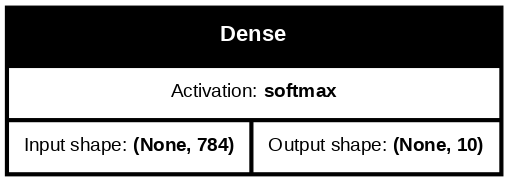

In [ ]:
def logistic_regression(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Input((n_inputs,)))
  model.add(Dense(n_outputs,activation='softmax'))
  return model

model = logistic_regression(X_train.shape[1], 10)
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss="categorical_crossentropy", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True,rankdir='LR',dpi=100)

Epoch 1/50
600/600 - 2s - 3ms/step - accuracy: 0.9280 - loss: 0.2578 - val_accuracy: 0.9200 - val_loss: 0.3533
Epoch 2/50
600/600 - 2s - 3ms/step - accuracy: 0.9282 - loss: 0.2578 - val_accuracy: 0.9134 - val_loss: 0.3611
Epoch 3/50
600/600 - 1s - 2ms/step - accuracy: 0.9284 - loss: 0.2602 - val_accuracy: 0.9148 - val_loss: 0.3637
Epoch 4/50
600/600 - 3s - 4ms/step - accuracy: 0.9301 - loss: 0.2545 - val_accuracy: 0.9156 - val_loss: 0.3606
Epoch 5/50
600/600 - 1s - 2ms/step - accuracy: 0.9285 - loss: 0.2564 - val_accuracy: 0.9148 - val_loss: 0.3755
Epoch 6/50
600/600 - 4s - 7ms/step - accuracy: 0.9269 - loss: 0.2582 - val_accuracy: 0.9168 - val_loss: 0.3611
Epoch 7/50
600/600 - 1s - 2ms/step - accuracy: 0.9293 - loss: 0.2544 - val_accuracy: 0.9180 - val_loss: 0.3692
Epoch 8/50
600/600 - 3s - 4ms/step - accuracy: 0.9289 - loss: 0.2553 - val_accuracy: 0.9173 - val_loss: 0.3647
Epoch 9/50
600/600 - 3s - 4ms/step - accuracy: 0.9273 - loss: 0.2592 - val_accuracy: 0.9151 - val_loss: 0.3642
E

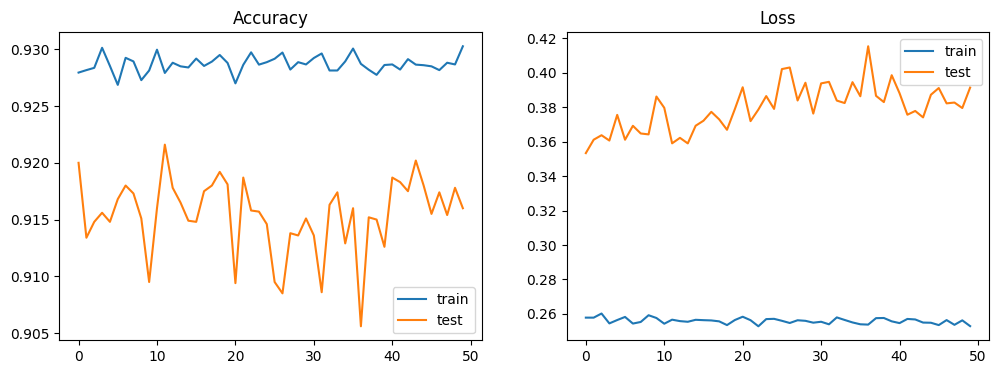

In [ ]:
start_train = time.time()
history = model.fit(
    X_train, y_train_oh,
    epochs = 50, batch_size = 100,
    verbose = 2,
    validation_data=(X_test, y_test_oh)
    )
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
plot_results(history)

y_pred = np.argmax(model.predict(X_test),axis=1)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Accuracy = {:5.3f}'.format(accuracy_score(y_pred,np.argmax(y_test_oh, axis=1))))
print('Confusion matrix')
print(confusion_matrix(np.argmax(y_test_oh,axis=1), y_pred))

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

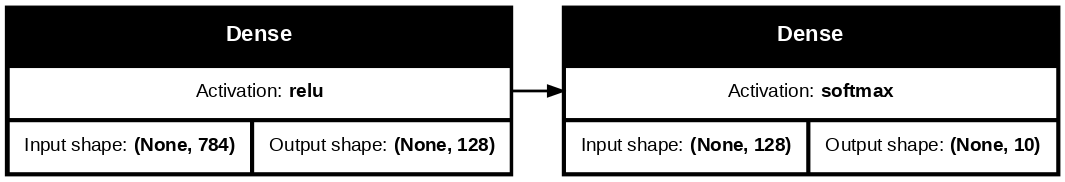

In [ ]:
def logistic_regression(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Input((n_inputs,)))
  model.add(Dense(128,activation='relu'))
  model.add(Dense(n_outputs,activation='softmax'))
  return model

model = logistic_regression(X_train.shape[1], 10)
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss="categorical_crossentropy", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True,rankdir='LR',dpi=100)

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

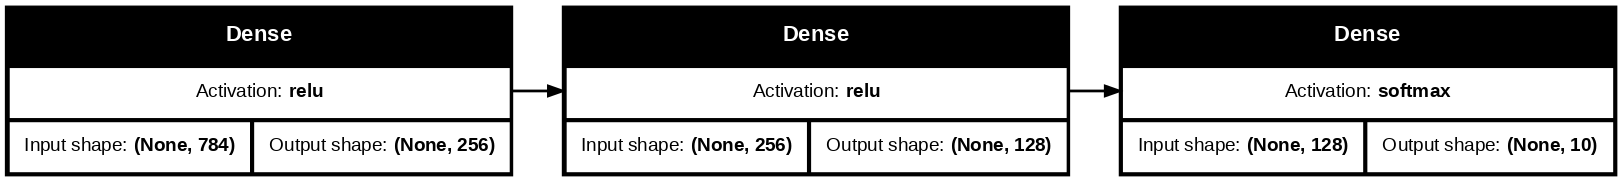

In [ ]:
def logistic_regression(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Input((n_inputs,)))
  model.add(Dense(256,activation='relu'))
  model.add(Dense(128,activation='relu'))
  model.add(Dense(n_outputs,activation='softmax'))
  return model

model = logistic_regression(X_train.shape[1], 10)
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss="categorical_crossentropy", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True,rankdir='LR',dpi=100)

## Multilayer Dense Architecture Experiments

A controlled sequence compares one linear layer, one sigmoid layer, two linear layers, two sigmoid layers, sigmoid-softmax combinations, and additional feed-forward configurations.

We will experiment to see if adding linear and/or nonlinear layers improves the networks performance.

In [ ]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

X_train = X_train.reshape(X_train.shape[0],-1)/255
X_test = X_test.reshape(X_test.shape[0],-1)/255

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

# Convert y to one-hot
print(y_train[:10])
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)
print(y_train[:10])

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)
(60000, 784)
(60000,)
(10000, 784)
(10000,)
[5 0 4 1 9 2 1 3 1 4]
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]
(60000, 784)
(60000, 10)
(10000, 784)
(10000, 10)


## **One linear layer**

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 10)                  │           7,850 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

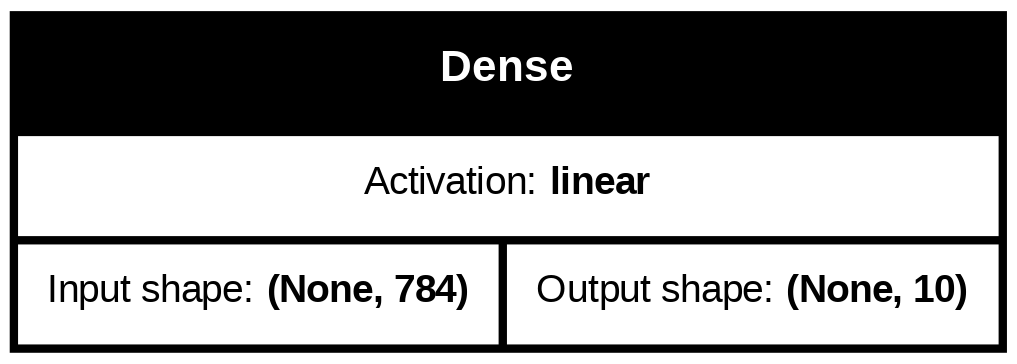

In [ ]:
def linear_regression():
  model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.Dense(10)])
  return model

model = linear_regression()
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(),loss="mse", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

Epoch 1/10
60/60 - 3s - 55ms/step - accuracy: 0.5238 - loss: 0.1027 - val_accuracy: 0.7430 - val_loss: 0.0616
Epoch 2/10
60/60 - 0s - 4ms/step - accuracy: 0.7814 - loss: 0.0553 - val_accuracy: 0.8198 - val_loss: 0.0496
Epoch 3/10
60/60 - 0s - 4ms/step - accuracy: 0.8195 - loss: 0.0480 - val_accuracy: 0.8367 - val_loss: 0.0455
Epoch 4/10
60/60 - 0s - 4ms/step - accuracy: 0.8309 - loss: 0.0449 - val_accuracy: 0.8471 - val_loss: 0.0436
Epoch 5/10
60/60 - 0s - 4ms/step - accuracy: 0.8375 - loss: 0.0432 - val_accuracy: 0.8512 - val_loss: 0.0423
Epoch 6/10
60/60 - 0s - 4ms/step - accuracy: 0.8414 - loss: 0.0422 - val_accuracy: 0.8550 - val_loss: 0.0414
Epoch 7/10
60/60 - 0s - 4ms/step - accuracy: 0.8440 - loss: 0.0414 - val_accuracy: 0.8520 - val_loss: 0.0409
Epoch 8/10
60/60 - 0s - 4ms/step - accuracy: 0.8449 - loss: 0.0409 - val_accuracy: 0.8595 - val_loss: 0.0405
Epoch 9/10
60/60 - 0s - 4ms/step - accuracy: 0.8485 - loss: 0.0404 - val_accuracy: 0.8562 - val_loss: 0.0401
Epoch 10/10
60/60 

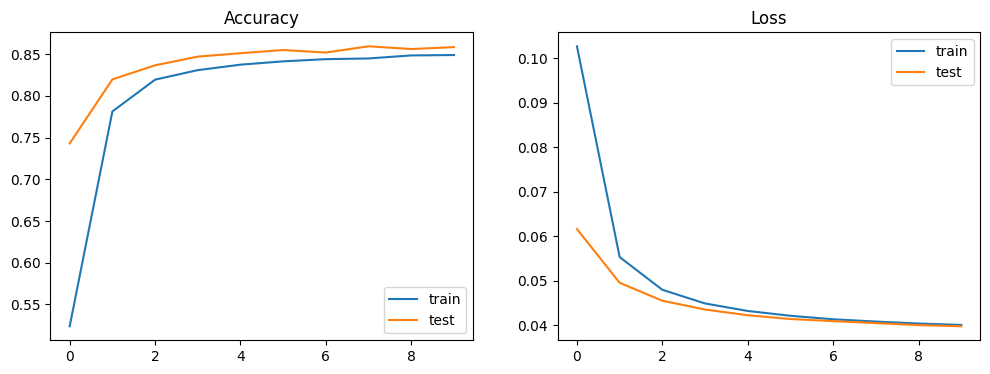

In [ ]:
start_train = time.time()
history = model.fit(
    X_train, y_train,
    epochs = 10,
    batch_size = 1000,
    verbose = 2,
    validation_data=(X_test, y_test),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(np.argmax(y_test,axis=1),np.argmax(pred,axis=1))))

## **One sigmoid layer**

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                      │ (None, 10)                  │           7,850 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

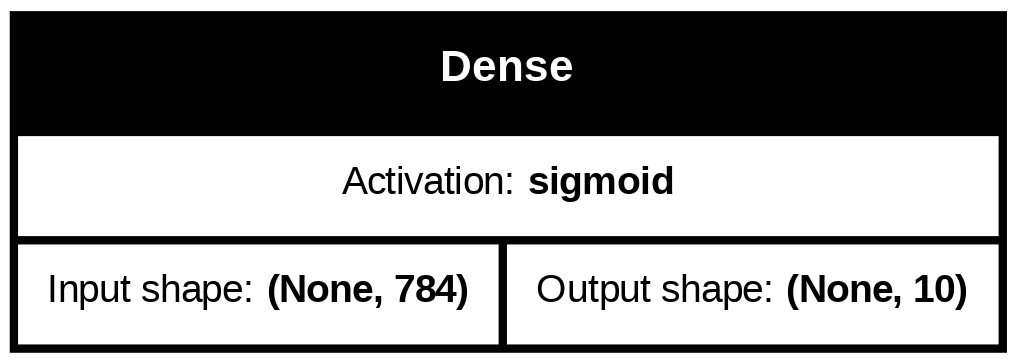

In [ ]:
def logistic_regression():
  model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.Dense(10,  activation='sigmoid')])
  return model

model = logistic_regression()
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(),loss="mse", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

Epoch 1/40
60/60 - 1s - 24ms/step - accuracy: 0.3137 - loss: 0.1047 - val_accuracy: 0.4993 - val_loss: 0.0776
Epoch 2/40
60/60 - 0s - 4ms/step - accuracy: 0.6114 - loss: 0.0660 - val_accuracy: 0.7284 - val_loss: 0.0559
Epoch 3/40
60/60 - 0s - 4ms/step - accuracy: 0.7582 - loss: 0.0507 - val_accuracy: 0.8099 - val_loss: 0.0450
Epoch 4/40
60/60 - 0s - 4ms/step - accuracy: 0.8212 - loss: 0.0423 - val_accuracy: 0.8435 - val_loss: 0.0387
Epoch 5/40
60/60 - 0s - 4ms/step - accuracy: 0.8435 - loss: 0.0371 - val_accuracy: 0.8581 - val_loss: 0.0345
Epoch 6/40
60/60 - 0s - 4ms/step - accuracy: 0.8555 - loss: 0.0337 - val_accuracy: 0.8672 - val_loss: 0.0316
Epoch 7/40
60/60 - 0s - 4ms/step - accuracy: 0.8636 - loss: 0.0312 - val_accuracy: 0.8733 - val_loss: 0.0295
Epoch 8/40
60/60 - 0s - 4ms/step - accuracy: 0.8705 - loss: 0.0293 - val_accuracy: 0.8784 - val_loss: 0.0279
Epoch 9/40
60/60 - 0s - 4ms/step - accuracy: 0.8746 - loss: 0.0279 - val_accuracy: 0.8831 - val_loss: 0.0266
Epoch 10/40
60/60 

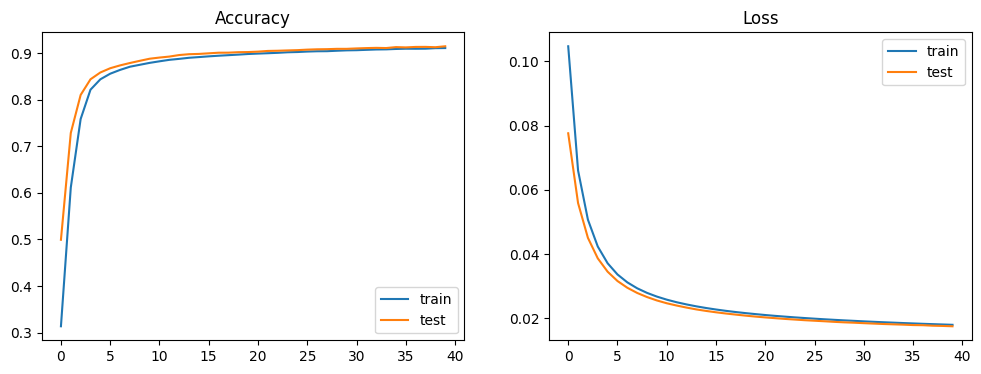

In [ ]:
start_train = time.time()
history = model.fit(
    X_train, y_train,
    epochs = 40,
    batch_size = 1000,
    verbose = 2,
    validation_data=(X_test, y_test),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(np.argmax(y_test,axis=1),np.argmax(pred,axis=1))))

In [ ]:
def plot_image(i, predictions_array, true_label, img):
  true_label, img = true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img, cmap='gray')

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% (True class: {})".format(predicted_label,
                                100*np.max(predictions_array),
                                true_label),
                                color=color)

def plot_value_array(i, predictions_array, true_label):
  true_label = true_label[i]
  plt.grid(False)
  plt.xticks(range(10))
  #plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

y_test_int = np.argmax(y_test,axis=1)
pred_int = np.argmax(pred,axis=1)

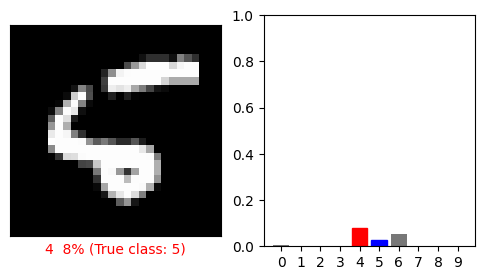

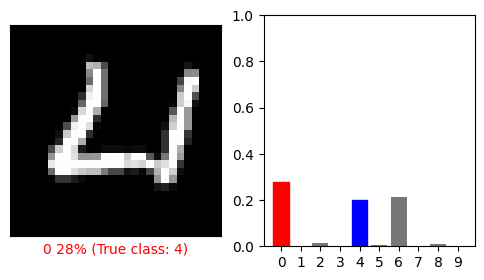

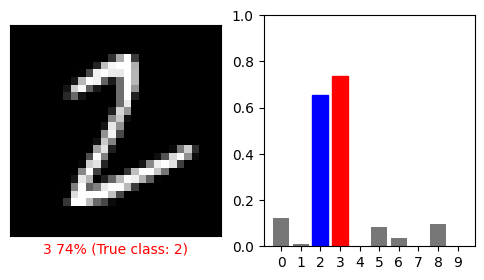

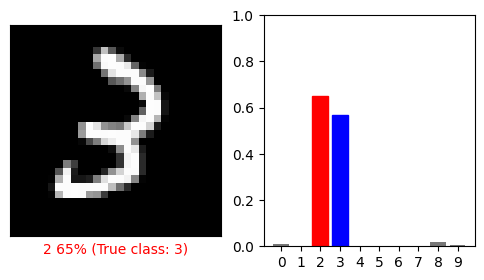

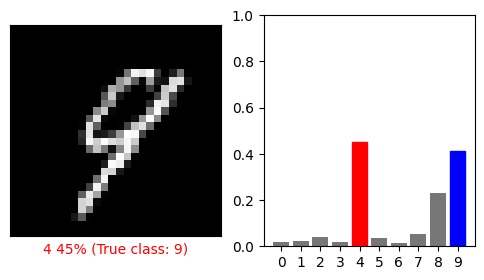

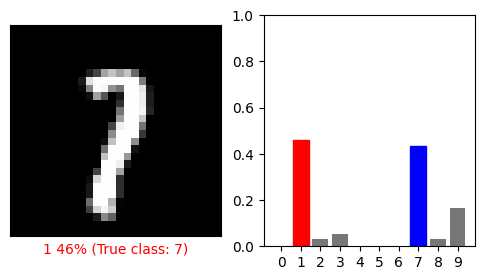

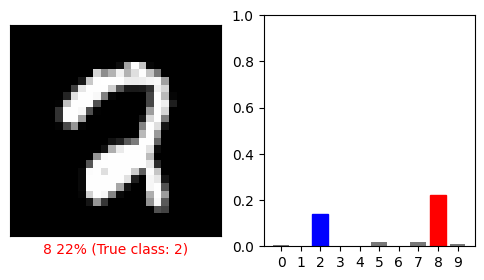

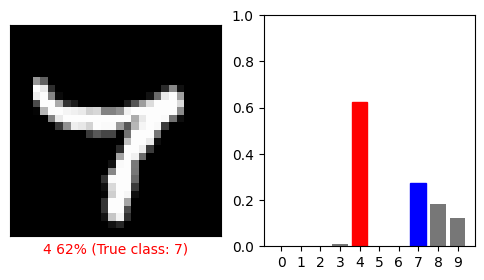

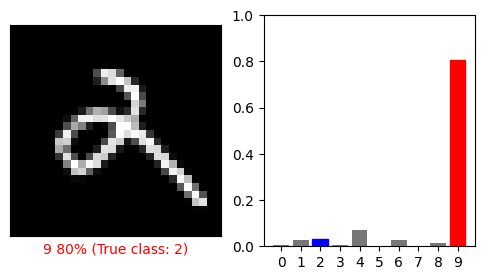

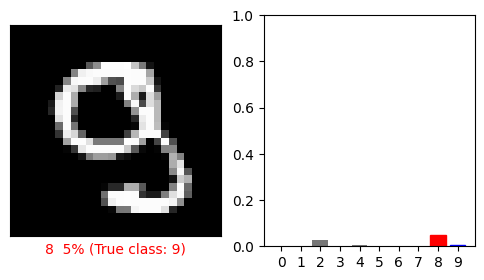

In [ ]:
i, count = 0, 0
while count<10:
  if pred_int[i]!= y_test_int[i]:
    plt.figure(figsize=(6,3))
    plt.subplot(1,2,1)
    plot_image(i, pred[i], y_test_int, X_test.reshape(-1,28,28))
    plt.subplot(1,2,2)
    plot_value_array(i, pred[i],  y_test_int)
    plt.show()
    count +=1
  i += 1

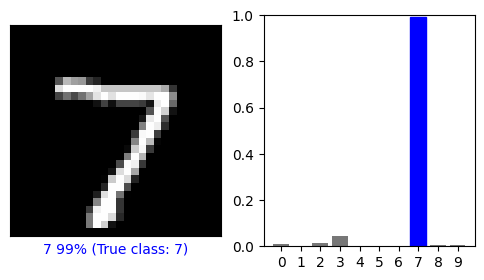

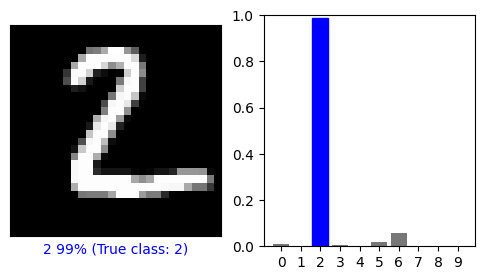

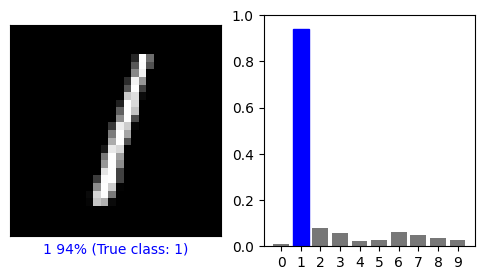

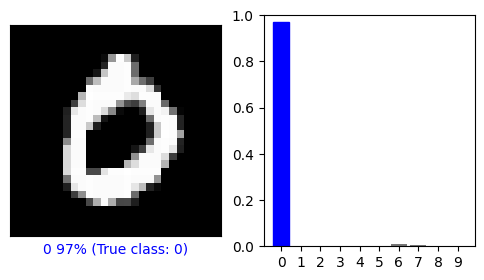

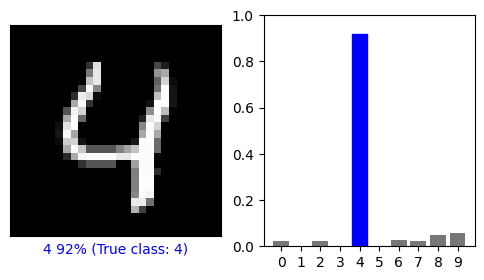

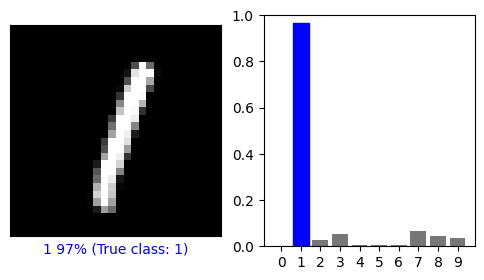

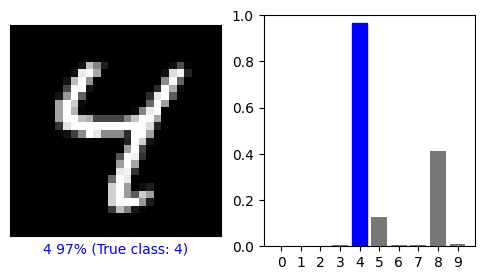

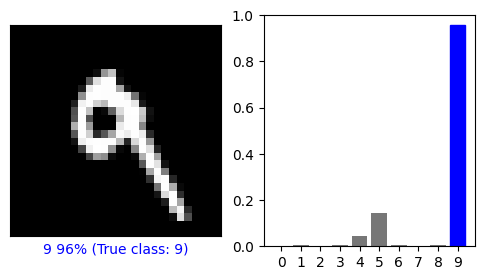

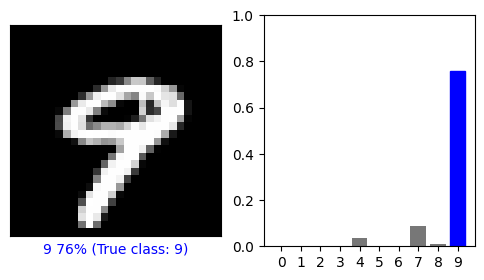

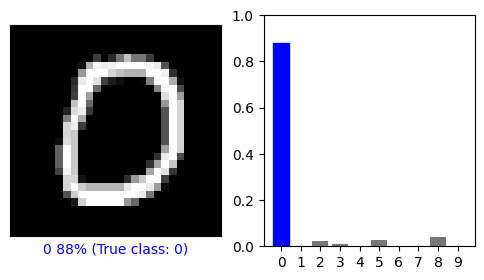

In [ ]:
i, count = 0, 0
while count<10:
  if pred_int[i]== y_test_int[i]:
    plt.figure(figsize=(6,3))
    plt.subplot(1,2,1)
    plot_image(i, pred[i], y_test_int, X_test.reshape(-1,28,28))
    plt.subplot(1,2,2)
    plot_value_array(i, pred[i],  y_test_int)
    plt.show()
    count +=1
  i += 1

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                      │ (None, 10)                  │           7,850 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
60/60 - 1s - 25ms/step - accuracy: 0.6117 - loss: 0.0610 - val_accuracy: 0.8171 - val_loss: 0.0355
Epoch 2/40
60/60 - 0s - 4ms/step - accuracy: 0.8450 - loss: 0.0293 - val_accuracy: 0.8750 - val_loss: 0.0235
Epoch 3/40
60/60 - 0s - 4ms/step - accuracy: 0.8765 - loss: 0.0224 - val_accuracy: 0.8912 - val_loss: 0.0196
Epoch 4/40
60/60 - 0s - 4ms/step - accuracy: 0.8891 - loss: 0.0195 - val_accuracy: 0.9006 - val_loss: 0.0176
Epoch 5/40
60/60 - 0s - 4ms/step - accuracy: 0.8972 - loss: 0.0177 - val_accuracy: 0.9052 - val_loss: 0.0163
Epoch 6/40
60/60 - 0s - 4ms/step - accuracy: 0.9026 - loss: 0.0166 - val_accuracy: 0.9090 - val_loss: 0.0153
Epoch 7/40
60/60 - 0s - 4ms/step - accuracy: 0.9061 - loss: 0.0157 - val_accuracy: 0.9121 - val_loss: 0.0146
Epoch 8/40
60/60 - 0s - 4ms/step - accuracy: 0.9090 - loss: 0.0150 - val_accuracy: 0.9139 - val_loss: 0.0141
Epoch 9/40
60/60 - 0s - 4ms/step - accuracy: 0.9125 - loss: 0.0145 - val_accuracy: 0.9155 - val_loss: 0.0137
Epoch 10/40
60/60 

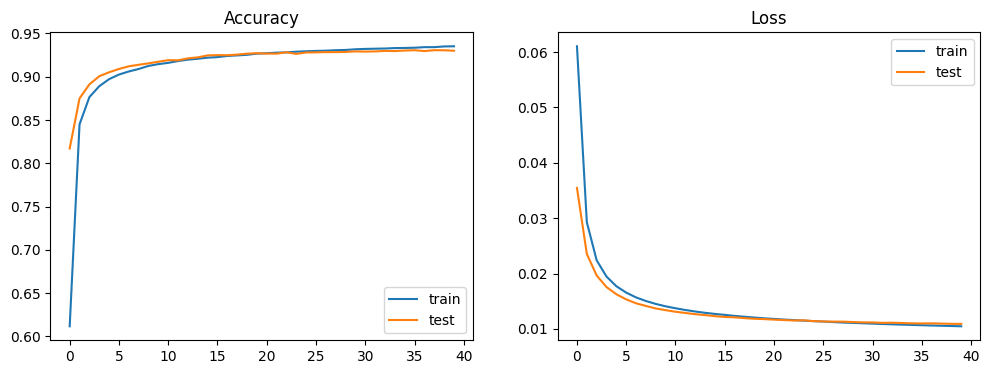

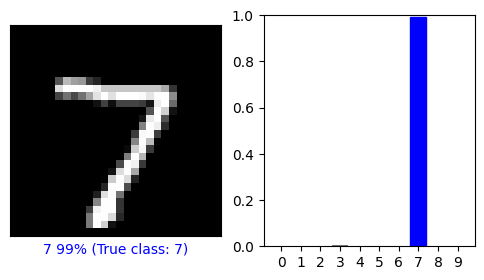

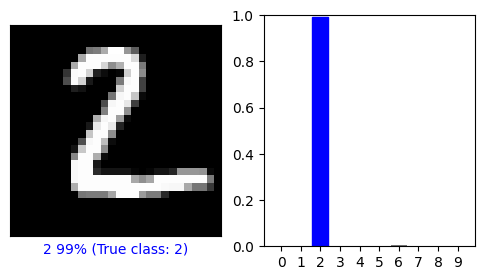

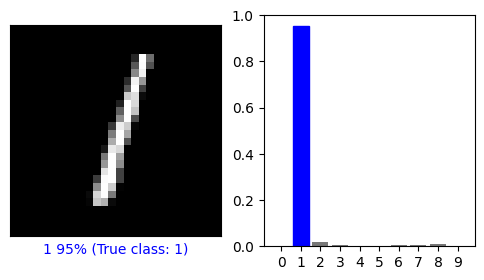

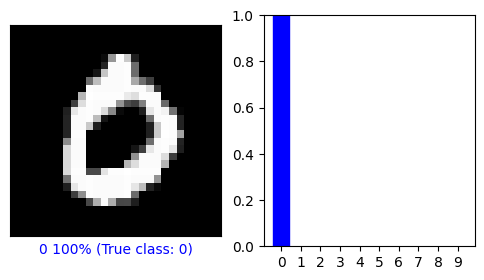

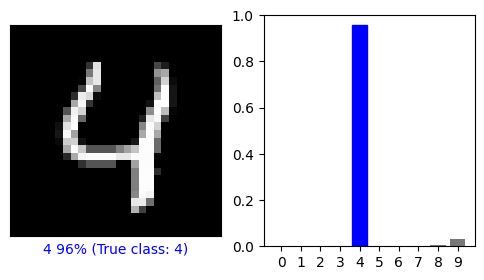

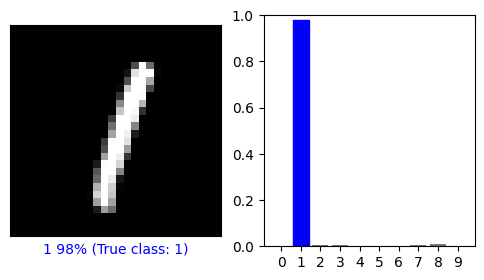

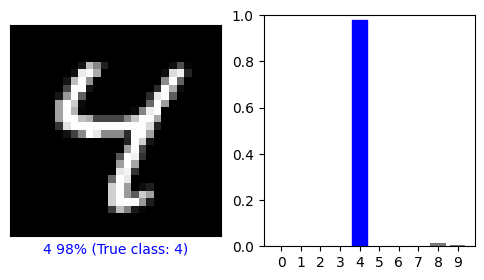

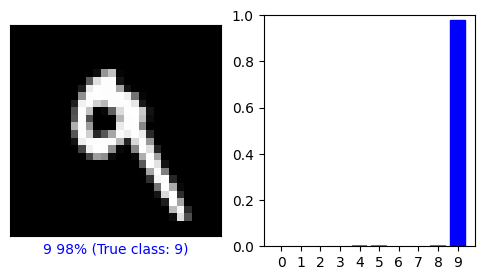

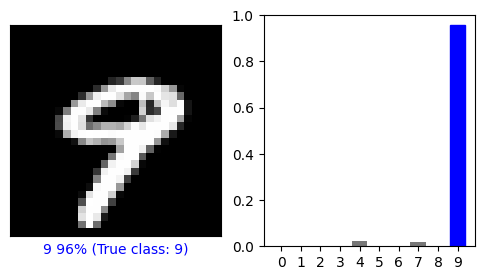

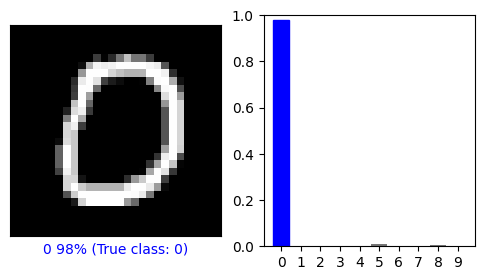

In [ ]:
def logistic_regression():
  model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.Dense(10,  activation='softmax')])
  return model

model = logistic_regression()
model.summary()
opt = tf.keras.optimizers.SGD(learning_rate=0.1,momentum=0.9)
model.compile(optimizer=tf.keras.optimizers.Adam(),loss="mse", metrics=["accuracy"])

plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

start_train = time.time()
history = model.fit(
    X_train, y_train,
    epochs = 40,
    batch_size = 1000,
    verbose = 2,
    validation_data=(X_test, y_test),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(np.argmax(y_test,axis=1),np.argmax(pred,axis=1))))

y_test_int = np.argmax(y_test,axis=1)
pred_int = np.argmax(pred,axis=1)

i, count = 0, 0
while count<10:
  if pred_int[i]== y_test_int[i]:
    plt.figure(figsize=(6,3))
    plt.subplot(1,2,1)
    plot_image(i, pred[i], y_test_int, X_test.reshape(-1,28,28))
    plt.subplot(1,2,2)
    plot_value_array(i, pred[i],  y_test_int)
    plt.show()
    count +=1
  i += 1

## **Two linear layers**

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 100)                 │          78,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 100)                 │          10,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 89,610 (350.04 KB)

 Trainable params: 89,610 (350.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
60/60 - 8s - 141ms/step - accuracy: 0.6656 - loss: 0.0899 - val_accuracy: 0.8233 - val_loss: 0.0474
Epoch 2/40
60/60 - 0s - 4ms/step - accuracy: 0.8272 - loss: 0.0450 - val_accuracy: 0.8470 - val_loss: 0.0422
Epoch 3/40
60/60 - 0s - 4ms/step - accuracy: 0.8419 - loss: 0.0419 - val_accuracy: 0.8541 - val_loss: 0.0406
Epoch 4/40
60/60 - 0s - 4ms/step - accuracy: 0.8467 - loss: 0.0406 - val_accuracy: 0.8555 - val_loss: 0.0399
Epoch 5/40
60/60 - 0s - 4ms/step - accuracy: 0.8483 - loss: 0.0400 - val_accuracy: 0.8590 - val_loss: 0.0395
Epoch 6/40
60/60 - 0s - 4ms/step - accuracy: 0.8507 - loss: 0.0396 - val_accuracy: 0.8574 - val_loss: 0.0392
Epoch 7/40
60/60 - 0s - 4ms/step - accuracy: 0.8510 - loss: 0.0394 - val_accuracy: 0.8591 - val_loss: 0.0390
Epoch 8/40
60/60 - 0s - 4ms/step - accuracy: 0.8517 - loss: 0.0392 - val_accuracy: 0.8600 - val_loss: 0.0391
Epoch 9/40
60/60 - 0s - 4ms/step - accuracy: 0.8530 - loss: 0.0391 - val_accuracy: 0.8598 - val_loss: 0.0388
Epoch 10/40
60/60

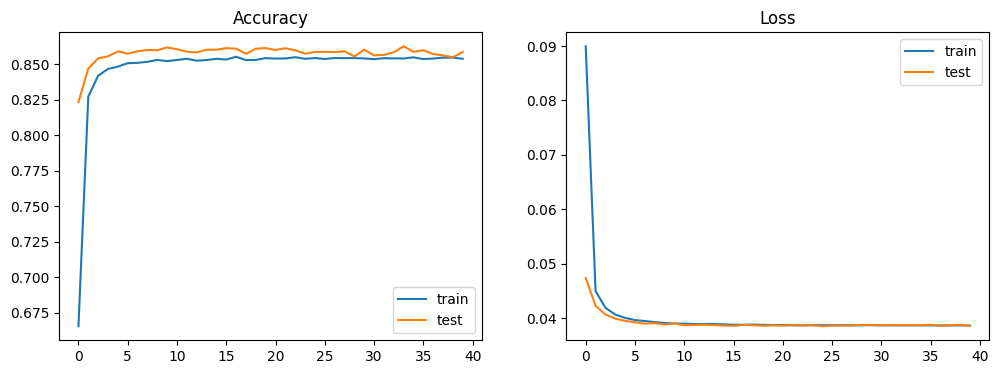

In [ ]:
def linear_two():
  model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10)])
  return model

model = linear_two()
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(),loss="mse", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

start_train = time.time()
history = model.fit(
    X_train, y_train,
    epochs = 40,
    batch_size = 1000,
    verbose = 2,
    validation_data=(X_test, y_test),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(np.argmax(y_test,axis=1),np.argmax(pred,axis=1))))

## **Two sigmoid layers**

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 100)                 │          78,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
60/60 - 5s - 82ms/step - accuracy: 0.4489 - loss: 0.0996 - val_accuracy: 0.6165 - val_loss: 0.0711
Epoch 2/40
60/60 - 0s - 4ms/step - accuracy: 0.7147 - loss: 0.0616 - val_accuracy: 0.8043 - val_loss: 0.0529
Epoch 3/40
60/60 - 0s - 4ms/step - accuracy: 0.8161 - loss: 0.0479 - val_accuracy: 0.8463 - val_loss: 0.0425
Epoch 4/40
60/60 - 0s - 4ms/step - accuracy: 0.8471 - loss: 0.0395 - val_accuracy: 0.8678 - val_loss: 0.0357
Epoch 5/40
60/60 - 0s - 4ms/step - accuracy: 0.8659 - loss: 0.0338 - val_accuracy: 0.8775 - val_loss: 0.0310
Epoch 6/40
60/60 - 0s - 4ms/step - accuracy: 0.8767 - loss: 0.0298 - val_accuracy: 0.8853 - val_loss: 0.0275
Epoch 7/40
60/60 - 0s - 4ms/step - accuracy: 0.8848 - loss: 0.0268 - val_accuracy: 0.8940 - val_loss: 0.0249
Epoch 8/40
60/60 - 0s - 4ms/step - accuracy: 0.8917 - loss: 0.0245 - val_accuracy: 0.8992 - val_loss: 0.0229
Epoch 9/40
60/60 - 0s - 4ms/step - accuracy: 0.8967 - loss: 0.0227 - val_accuracy: 0.9028 - val_loss: 0.0214
Epoch 10/40
60/60 

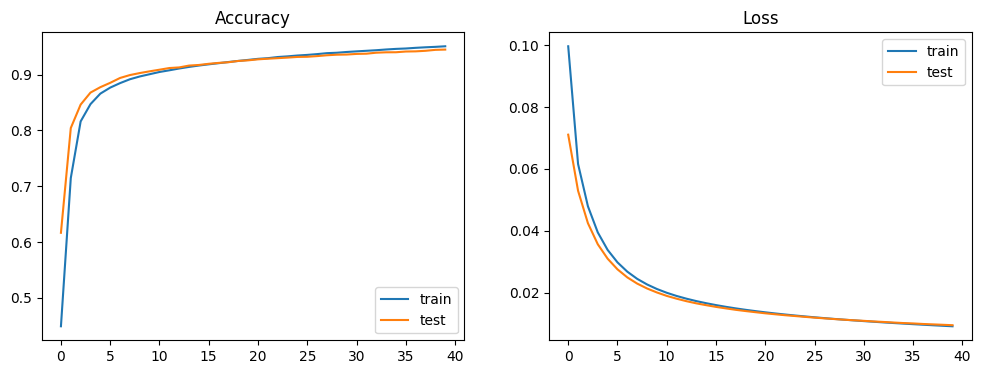

In [ ]:
def sigmoid_two():
  model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.Dense(100,  activation='sigmoid'),
    tf.keras.layers.Dense(10,  activation='sigmoid')])
  return model

model = sigmoid_two()
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(),loss="mse", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

start_train = time.time()
history = model.fit(
    X_train, y_train,
    epochs = 40,
    batch_size = 1000,
    verbose = 2,
    validation_data=(X_test, y_test),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(np.argmax(y_test,axis=1),np.argmax(pred,axis=1))))

## **One sigmoid layer and one softmax layer**

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                      │ (None, 100)                 │          78,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
60/60 - 2s - 36ms/step - accuracy: 0.6041 - loss: 0.0613 - val_accuracy: 0.8343 - val_loss: 0.0359
Epoch 2/40
60/60 - 0s - 4ms/step - accuracy: 0.8621 - loss: 0.0274 - val_accuracy: 0.8903 - val_loss: 0.0206
Epoch 3/40
60/60 - 0s - 4ms/step - accuracy: 0.8948 - loss: 0.0189 - val_accuracy: 0.9080 - val_loss: 0.0163
Epoch 4/40
60/60 - 0s - 4ms/step - accuracy: 0.9071 - loss: 0.0157 - val_accuracy: 0.9150 - val_loss: 0.0142
Epoch 5/40
60/60 - 0s - 5ms/step - accuracy: 0.9157 - loss: 0.0140 - val_accuracy: 0.9200 - val_loss: 0.0129
Epoch 6/40
60/60 - 0s - 4ms/step - accuracy: 0.9222 - loss: 0.0128 - val_accuracy: 0.9253 - val_loss: 0.0119
Epoch 7/40
60/60 - 0s - 4ms/step - accuracy: 0.9274 - loss: 0.0119 - val_accuracy: 0.9291 - val_loss: 0.0113
Epoch 8/40
60/60 - 0s - 4ms/step - accuracy: 0.9321 - loss: 0.0111 - val_accuracy: 0.9330 - val_loss: 0.0107
Epoch 9/40
60/60 - 0s - 4ms/step - accuracy: 0.9353 - loss: 0.0105 - val_accuracy: 0.9358 - val_loss: 0.0102
Epoch 10/40
60/60 

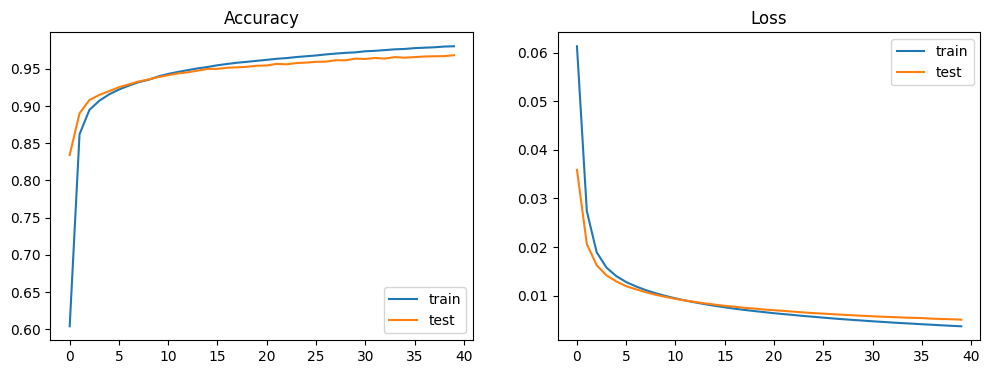

In [ ]:
def sigmoid_softmax():
  model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.Dense(100,  activation='sigmoid'),
    tf.keras.layers.Dense(10,  activation='softmax')])
  return model

model = sigmoid_softmax()
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(),loss="mse", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

start_train = time.time()
history = model.fit(
    X_train, y_train,
    epochs = 40,
    batch_size = 1000,
    verbose = 2,
    validation_data=(X_test, y_test),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(np.argmax(y_test,axis=1),np.argmax(pred,axis=1))))

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                     │ (None, 800)                 │         628,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 800)                 │         640,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 10)                  │           8,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,276,810 (4.87 MB)

 Trainable params: 1,276,810 (4.87 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
60/60 - 9s - 143ms/step - accuracy: 0.8875 - loss: 0.4022 - val_accuracy: 0.9499 - val_loss: 0.1714
Epoch 2/40
60/60 - 0s - 4ms/step - accuracy: 0.9610 - loss: 0.1321 - val_accuracy: 0.9671 - val_loss: 0.1082
Epoch 3/40
60/60 - 0s - 4ms/step - accuracy: 0.9752 - loss: 0.0841 - val_accuracy: 0.9715 - val_loss: 0.0941
Epoch 4/40
60/60 - 0s - 4ms/step - accuracy: 0.9828 - loss: 0.0589 - val_accuracy: 0.9771 - val_loss: 0.0750
Epoch 5/40
60/60 - 0s - 5ms/step - accuracy: 0.9880 - loss: 0.0407 - val_accuracy: 0.9792 - val_loss: 0.0673
Epoch 6/40
60/60 - 0s - 4ms/step - accuracy: 0.9923 - loss: 0.0276 - val_accuracy: 0.9802 - val_loss: 0.0650
Epoch 7/40
60/60 - 0s - 4ms/step - accuracy: 0.9947 - loss: 0.0200 - val_accuracy: 0.9796 - val_loss: 0.0676
Epoch 8/40
60/60 - 0s - 4ms/step - accuracy: 0.9966 - loss: 0.0142 - val_accuracy: 0.9822 - val_loss: 0.0625
Epoch 9/40
60/60 - 0s - 4ms/step - accuracy: 0.9981 - loss: 0.0095 - val_accuracy: 0.9804 - val_loss: 0.0645
Epoch 10/40
60/60

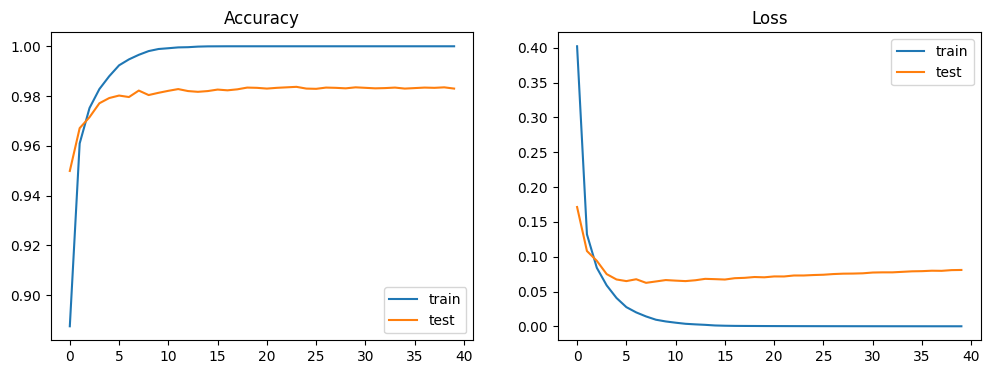

In [ ]:
def ffnn():
  model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.Dense(800,  activation='relu'),
    tf.keras.layers.Dense(800,  activation='relu'),
    tf.keras.layers.Dense(10,  activation='softmax')])
  return model

model = ffnn()
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(),loss="CategoricalCrossentropy", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

start_train = time.time()
history = model.fit(
    X_train, y_train,
    epochs = 40,
    batch_size = 1000,
    verbose = 2,
    validation_data=(X_test, y_test),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(np.argmax(y_test,axis=1),np.argmax(pred,axis=1))))

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                     │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
60/60 - 8s - 131ms/step - accuracy: 0.8085 - loss: 0.7272 - val_accuracy: 0.9194 - val_loss: 0.2888
Epoch 2/40
60/60 - 0s - 4ms/step - accuracy: 0.9283 - loss: 0.2493 - val_accuracy: 0.9408 - val_loss: 0.2069
Epoch 3/40
60/60 - 0s - 4ms/step - accuracy: 0.9470 - loss: 0.1832 - val_accuracy: 0.9517 - val_loss: 0.1644
Epoch 4/40
60/60 - 0s - 4ms/step - accuracy: 0.9568 - loss: 0.1482 - val_accuracy: 0.9569 - val_loss: 0.1428
Epoch 5/40
60/60 - 0s - 4ms/step - accuracy: 0.9647 - loss: 0.1218 - val_accuracy: 0.9625 - val_loss: 0.1261
Epoch 6/40
60/60 - 0s - 4ms/step - accuracy: 0.9690 - loss: 0.1035 - val_accuracy: 0.9659 - val_loss: 0.1106
Epoch 7/40
60/60 - 0s - 4ms/step - accuracy: 0.9740 - loss: 0.0890 - val_accuracy: 0.9686 - val_loss: 0.1052
Epoch 8/40
60/60 - 0s - 4ms/step - accuracy: 0.9769 - loss: 0.0773 - val_accuracy: 0.9702 - val_loss: 0.1011
Epoch 9/40
60/60 - 0s - 4ms/step - accuracy: 0.9804 - loss: 0.0674 - val_accuracy: 0.9727 - val_loss: 0.0913
Epoch 10/40
60/60

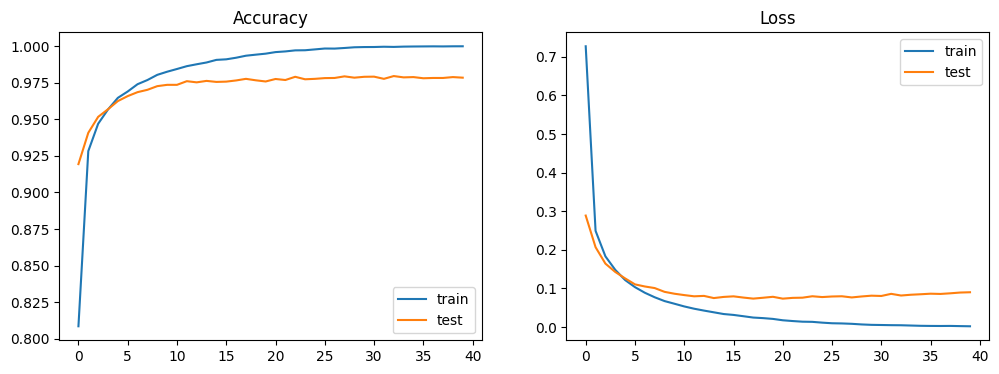

In [ ]:
def ffnn():
  model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.Dense(128,  activation='relu'),
    tf.keras.layers.Dense(128,  activation='relu'),
    #tf.keras.layers.Dense(800,  activation='relu'),
    tf.keras.layers.Dense(10,  activation='softmax')])
  return model

model = ffnn()
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(),loss="CategoricalCrossentropy", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

start_train = time.time()
history = model.fit(
    X_train, y_train,
    epochs = 40,
    batch_size = 1000,
    verbose = 2,
    validation_data=(X_test, y_test),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(np.argmax(y_test,axis=1),np.argmax(pred,axis=1))))

## Hyperparameter and Feature-Order Experiments

The one-hidden-layer network is evaluated across multiple epoch, batch-size, and learning-rate settings, followed by a fixed column-shuffling experiment.

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
from keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.activations import *
from keras.utils import plot_model
from sklearn.metrics import accuracy_score, confusion_matrix,mean_squared_error,mean_absolute_error
import time

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
X_train.shape=(60000, 784)
X_test.shape=(10000, 784)
y_train.shape=(60000,)
y_test.shape=(10000,)
y_train_oh.shape=(60000, 10)
y_test_oh.shape=(10000, 10)


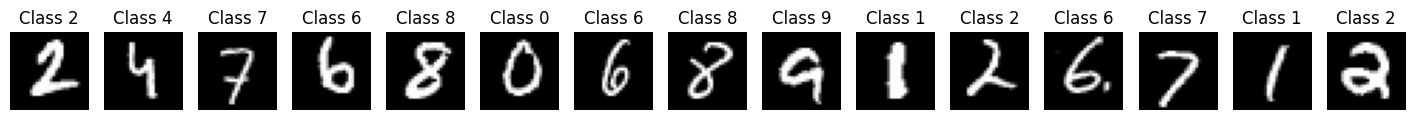

In [ ]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

X_train = np.float32(X_train.reshape(X_train.shape[0],-1))/255
X_test = np.float32(X_test.reshape(X_test.shape[0],-1))/255
y_train_oh = tf.keras.utils.to_categorical(y_train, 10)
y_test_oh = tf.keras.utils.to_categorical(y_test, 10)
print(f'{X_train.shape=}')
print(f'{X_test.shape=}')
print(f'{y_train.shape=}')
print(f'{y_test.shape=}')
print(f'{y_train_oh.shape=}')
print(f'{y_test_oh.shape=}')

y_train_oh = tf.keras.utils.to_categorical(y_train, 10)
y_test_oh = tf.keras.utils.to_categorical(y_test, 10)

nimgs = 15
sel = np.random.randint(0,X_train.shape[0],size =nimgs)
fig, ax = plt.subplots(ncols=nimgs, figsize=(18,4))
for i, s in enumerate(sel):
  ax[i].imshow(X_train[s].reshape(28,28),cmap='gray')
  ax[i].set_title(f'Class {y_train[s]}')
  ax[i].set_axis_off()
plt.show()

## Hyperparameter Sensitivity

Evaluate the performance of the network with one hidden layer on the MNIST dataset when you modify.

*   Number of epochs
*   Batch size
*   Learning rate

For each experiment, write a paragraph describing your results.

In [ ]:
def ffnn_one_HL(n_inputs, hidden, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Input((n_inputs,)))
  model.add(Dense(hidden,activation='relu'))
  model.add(Dense(n_outputs,activation='softmax'))
  return model

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 397,510 (1.52 MB)

 Trainable params: 397,510 (1.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
240/240 - 2s - 10ms/step - accuracy: 0.9334 - loss: 0.2149 - val_accuracy: 0.9598 - val_loss: 0.1349
Epoch 2/10
240/240 - 1s - 3ms/step - accuracy: 0.9715 - loss: 0.0925 - val_accuracy: 0.9706 - val_loss: 0.0943
Epoch 3/10
240/240 - 1s - 3ms/step - accuracy: 0.9771 - loss: 0.0727 - val_accuracy: 0.9632 - val_loss: 0.1242
Epoch 4/10
240/240 - 1s - 3ms/step - accuracy: 0.9812 - loss: 0.0586 - val_accuracy: 0.9717 - val_loss: 0.1017
Epoch 5/10
240/240 - 1s - 2ms/step - accuracy: 0.9832 - loss: 0.0533 - val_accuracy: 0.9747 - val_loss: 0.1005
Epoch 6/10
240/240 - 1s - 2ms/step - accuracy: 0.9856 - loss: 0.0461 - val_accuracy: 0.9739 - val_loss: 0.1163
Epoch 7/10
240/240 - 1s - 2ms/step - accuracy: 0.9861 - loss: 0.0458 - val_accuracy: 0.9676 - val_loss: 0.1460
Epoch 8/10
240/240 - 1s - 2ms/step - accuracy: 0.9853 - loss: 0.0509 - val_accuracy: 0.9725 - val_loss: 0.1464
Epoch 9/10
240/240 - 1s - 2ms/step - accuracy: 0.9884 - loss: 0.0394 - val_accuracy: 0.9758 - val_loss: 0.1218


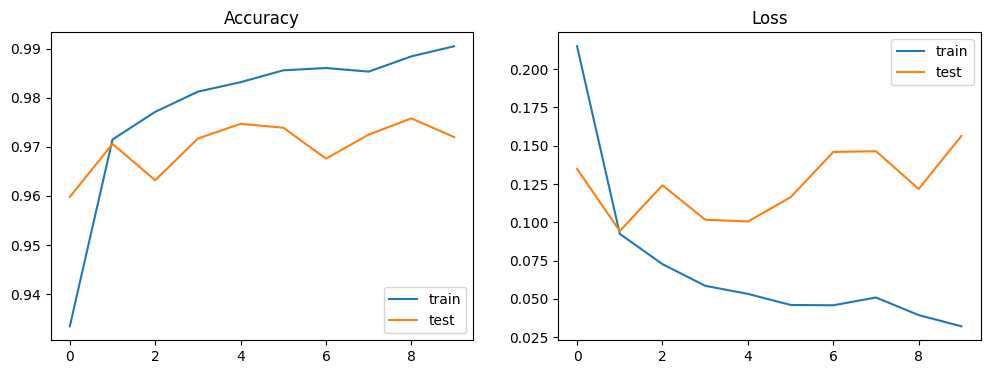

In [ ]:
model = ffnn_one_HL(X_train.shape[1], 500 ,y_train_oh.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss="categorical_crossentropy", metrics=["accuracy"])

start_train = time.time()
history = model.fit(
    X_train, y_train_oh,
    epochs = 10,
    batch_size = 250,
    verbose = 2,
    validation_data=(X_test, y_test_oh),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(y_test,np.argmax(pred,axis=1))))

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 397,510 (1.52 MB)

 Trainable params: 397,510 (1.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
240/240 - 2s - 9ms/step - accuracy: 0.9125 - loss: 0.3208 - val_accuracy: 0.9534 - val_loss: 0.1607
Epoch 2/10
240/240 - 1s - 2ms/step - accuracy: 0.9623 - loss: 0.1349 - val_accuracy: 0.9668 - val_loss: 0.1099
Epoch 3/10
240/240 - 1s - 3ms/step - accuracy: 0.9741 - loss: 0.0912 - val_accuracy: 0.9738 - val_loss: 0.0865
Epoch 4/10
240/240 - 1s - 3ms/step - accuracy: 0.9810 - loss: 0.0663 - val_accuracy: 0.9763 - val_loss: 0.0769
Epoch 5/10
240/240 - 1s - 3ms/step - accuracy: 0.9851 - loss: 0.0514 - val_accuracy: 0.9774 - val_loss: 0.0710
Epoch 6/10
240/240 - 1s - 3ms/step - accuracy: 0.9887 - loss: 0.0409 - val_accuracy: 0.9782 - val_loss: 0.0658
Epoch 7/10
240/240 - 1s - 3ms/step - accuracy: 0.9915 - loss: 0.0318 - val_accuracy: 0.9791 - val_loss: 0.0639
Epoch 8/10
240/240 - 1s - 2ms/step - accuracy: 0.9938 - loss: 0.0249 - val_accuracy: 0.9802 - val_loss: 0.0644
Epoch 9/10
240/240 - 1s - 2ms/step - accuracy: 0.9957 - loss: 0.0196 - val_accuracy: 0.9790 - val_loss: 0.0685
E

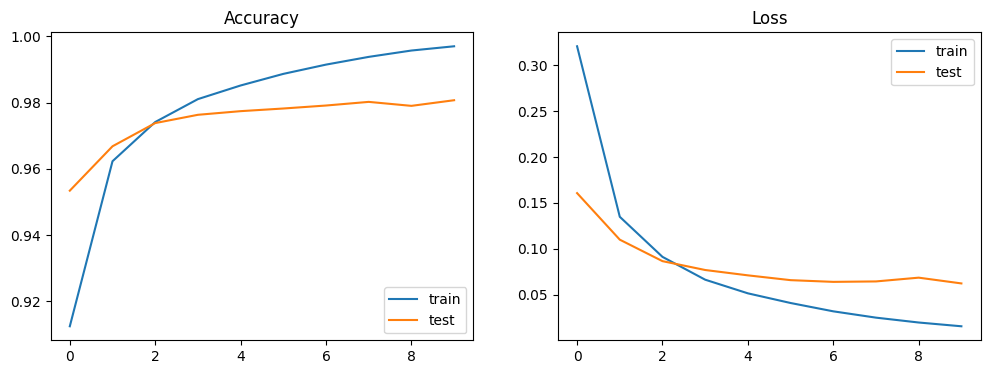

In [ ]:
model = ffnn_one_HL(X_train.shape[1], 500 ,y_train_oh.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="categorical_crossentropy", metrics=["accuracy"])

start_train = time.time()
history = model.fit(
    X_train, y_train_oh,
    epochs = 10,
    batch_size = 250,
    verbose = 2,
    validation_data=(X_test, y_test_oh),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(y_test,np.argmax(pred,axis=1))))

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 397,510 (1.52 MB)

 Trainable params: 397,510 (1.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
120/120 - 2s - 16ms/step - accuracy: 0.9147 - loss: 0.2873 - val_accuracy: 0.9659 - val_loss: 0.1095
Epoch 2/10
120/120 - 0s - 3ms/step - accuracy: 0.9720 - loss: 0.0892 - val_accuracy: 0.9704 - val_loss: 0.0927
Epoch 3/10
120/120 - 0s - 3ms/step - accuracy: 0.9807 - loss: 0.0602 - val_accuracy: 0.9775 - val_loss: 0.0781
Epoch 4/10
120/120 - 0s - 3ms/step - accuracy: 0.9868 - loss: 0.0411 - val_accuracy: 0.9772 - val_loss: 0.0765
Epoch 5/10
120/120 - 0s - 3ms/step - accuracy: 0.9891 - loss: 0.0329 - val_accuracy: 0.9757 - val_loss: 0.0835
Epoch 6/10
120/120 - 0s - 3ms/step - accuracy: 0.9895 - loss: 0.0317 - val_accuracy: 0.9786 - val_loss: 0.0807
Epoch 7/10
120/120 - 0s - 3ms/step - accuracy: 0.9926 - loss: 0.0222 - val_accuracy: 0.9738 - val_loss: 0.0951
Epoch 8/10
120/120 - 0s - 3ms/step - accuracy: 0.9931 - loss: 0.0209 - val_accuracy: 0.9763 - val_loss: 0.0989
Epoch 9/10
120/120 - 0s - 3ms/step - accuracy: 0.9924 - loss: 0.0226 - val_accuracy: 0.9757 - val_loss: 0.1042


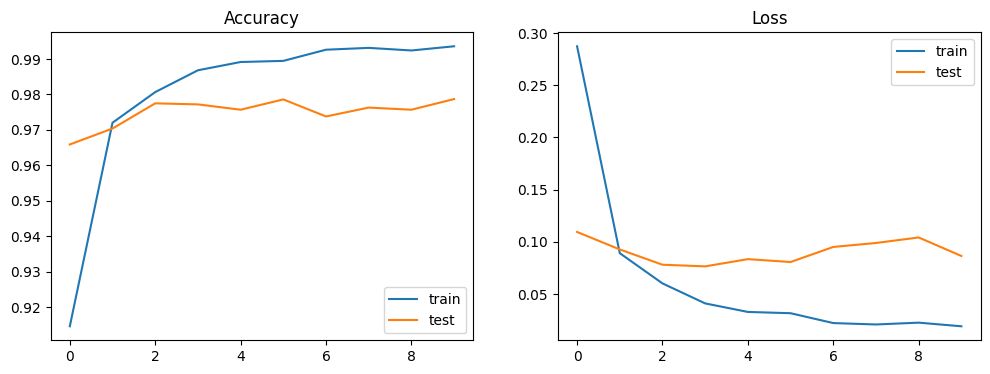

In [ ]:
model = ffnn_one_HL(X_train.shape[1], 500 ,y_train_oh.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss="categorical_crossentropy", metrics=["accuracy"])

start_train = time.time()
history = model.fit(
    X_train, y_train_oh,
    epochs = 10,
    batch_size = 500,
    verbose = 2,
    validation_data=(X_test, y_test_oh),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(y_test,np.argmax(pred,axis=1))))

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 397,510 (1.52 MB)

 Trainable params: 397,510 (1.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
120/120 - 2s - 16ms/step - accuracy: 0.8873 - loss: 0.4165 - val_accuracy: 0.9419 - val_loss: 0.2061
Epoch 2/10
120/120 - 0s - 3ms/step - accuracy: 0.9504 - loss: 0.1758 - val_accuracy: 0.9587 - val_loss: 0.1429
Epoch 3/10
120/120 - 0s - 3ms/step - accuracy: 0.9656 - loss: 0.1228 - val_accuracy: 0.9680 - val_loss: 0.1119
Epoch 4/10
120/120 - 0s - 3ms/step - accuracy: 0.9740 - loss: 0.0937 - val_accuracy: 0.9712 - val_loss: 0.0983
Epoch 5/10
120/120 - 0s - 3ms/step - accuracy: 0.9793 - loss: 0.0743 - val_accuracy: 0.9738 - val_loss: 0.0862
Epoch 6/10
120/120 - 0s - 3ms/step - accuracy: 0.9835 - loss: 0.0601 - val_accuracy: 0.9763 - val_loss: 0.0779
Epoch 7/10
120/120 - 0s - 3ms/step - accuracy: 0.9864 - loss: 0.0499 - val_accuracy: 0.9780 - val_loss: 0.0739
Epoch 8/10
120/120 - 0s - 3ms/step - accuracy: 0.9887 - loss: 0.0419 - val_accuracy: 0.9794 - val_loss: 0.0695
Epoch 9/10
120/120 - 0s - 3ms/step - accuracy: 0.9912 - loss: 0.0346 - val_accuracy: 0.9787 - val_loss: 0.0681


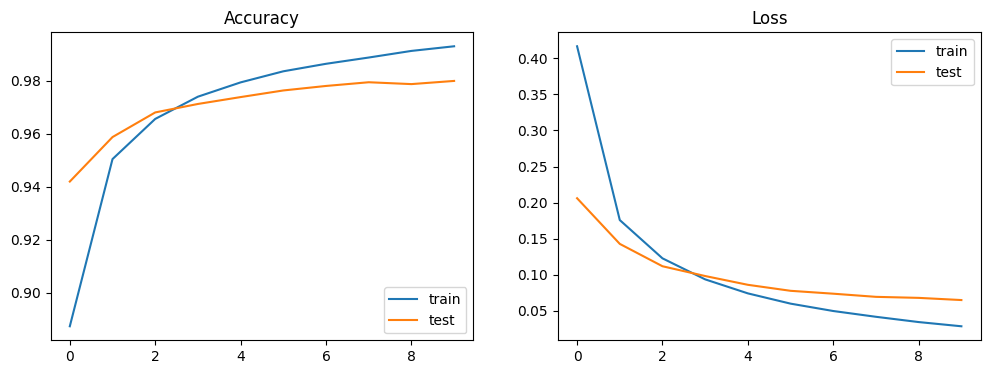

In [ ]:
model = ffnn_one_HL(X_train.shape[1], 500 ,y_train_oh.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="categorical_crossentropy", metrics=["accuracy"])

start_train = time.time()
history = model.fit(
    X_train, y_train_oh,
    epochs = 10,
    batch_size = 500,
    verbose = 2,
    validation_data=(X_test, y_test_oh),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(y_test,np.argmax(pred,axis=1))))

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_26 (Dense)                │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 397,510 (1.52 MB)

 Trainable params: 397,510 (1.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
240/240 - 2s - 10ms/step - accuracy: 0.9299 - loss: 0.2354 - val_accuracy: 0.9648 - val_loss: 0.1105
Epoch 2/20
240/240 - 1s - 3ms/step - accuracy: 0.9712 - loss: 0.0937 - val_accuracy: 0.9698 - val_loss: 0.1025
Epoch 3/20
240/240 - 1s - 3ms/step - accuracy: 0.9793 - loss: 0.0641 - val_accuracy: 0.9734 - val_loss: 0.0948
Epoch 4/20
240/240 - 1s - 3ms/step - accuracy: 0.9827 - loss: 0.0549 - val_accuracy: 0.9642 - val_loss: 0.1393
Epoch 5/20
240/240 - 1s - 3ms/step - accuracy: 0.9840 - loss: 0.0520 - val_accuracy: 0.9695 - val_loss: 0.1276
Epoch 6/20
240/240 - 1s - 3ms/step - accuracy: 0.9860 - loss: 0.0453 - val_accuracy: 0.9726 - val_loss: 0.1204
Epoch 7/20
240/240 - 1s - 3ms/step - accuracy: 0.9877 - loss: 0.0394 - val_accuracy: 0.9755 - val_loss: 0.0971
Epoch 8/20
240/240 - 1s - 3ms/step - accuracy: 0.9892 - loss: 0.0349 - val_accuracy: 0.9777 - val_loss: 0.1074
Epoch 9/20
240/240 - 1s - 3ms/step - accuracy: 0.9891 - loss: 0.0350 - val_accuracy: 0.9734 - val_loss: 0.1364


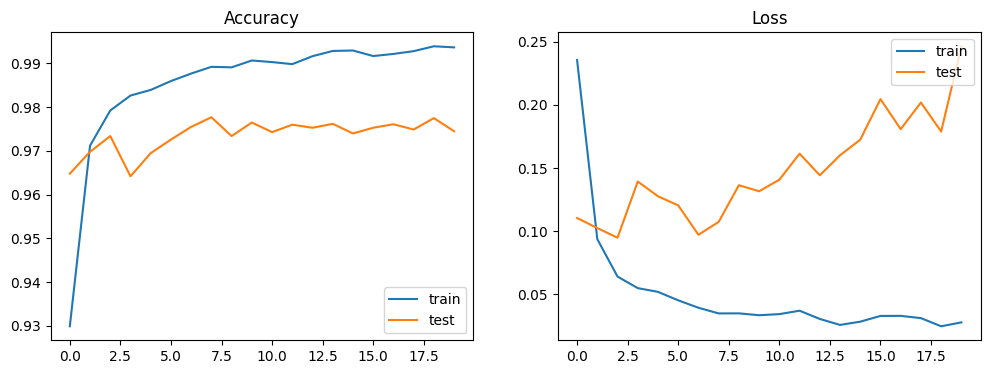

In [ ]:
model = ffnn_one_HL(X_train.shape[1], 500 ,y_train_oh.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss="categorical_crossentropy", metrics=["accuracy"])

start_train = time.time()
history = model.fit(
    X_train, y_train_oh,
    epochs = 20,
    batch_size = 250,
    verbose = 2,
    validation_data=(X_test, y_test_oh),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(y_test,np.argmax(pred,axis=1))))

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 397,510 (1.52 MB)

 Trainable params: 397,510 (1.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
240/240 - 2s - 9ms/step - accuracy: 0.9086 - loss: 0.3264 - val_accuracy: 0.9521 - val_loss: 0.1626
Epoch 2/20
240/240 - 1s - 3ms/step - accuracy: 0.9611 - loss: 0.1371 - val_accuracy: 0.9652 - val_loss: 0.1163
Epoch 3/20
240/240 - 1s - 3ms/step - accuracy: 0.9736 - loss: 0.0931 - val_accuracy: 0.9737 - val_loss: 0.0902
Epoch 4/20
240/240 - 1s - 3ms/step - accuracy: 0.9814 - loss: 0.0676 - val_accuracy: 0.9766 - val_loss: 0.0777
Epoch 5/20
240/240 - 1s - 3ms/step - accuracy: 0.9855 - loss: 0.0519 - val_accuracy: 0.9749 - val_loss: 0.0805
Epoch 6/20
240/240 - 1s - 3ms/step - accuracy: 0.9885 - loss: 0.0416 - val_accuracy: 0.9792 - val_loss: 0.0679
Epoch 7/20
240/240 - 1s - 3ms/step - accuracy: 0.9910 - loss: 0.0325 - val_accuracy: 0.9785 - val_loss: 0.0675
Epoch 8/20
240/240 - 1s - 2ms/step - accuracy: 0.9938 - loss: 0.0253 - val_accuracy: 0.9803 - val_loss: 0.0625
Epoch 9/20
240/240 - 1s - 3ms/step - accuracy: 0.9953 - loss: 0.0200 - val_accuracy: 0.9799 - val_loss: 0.0640
E

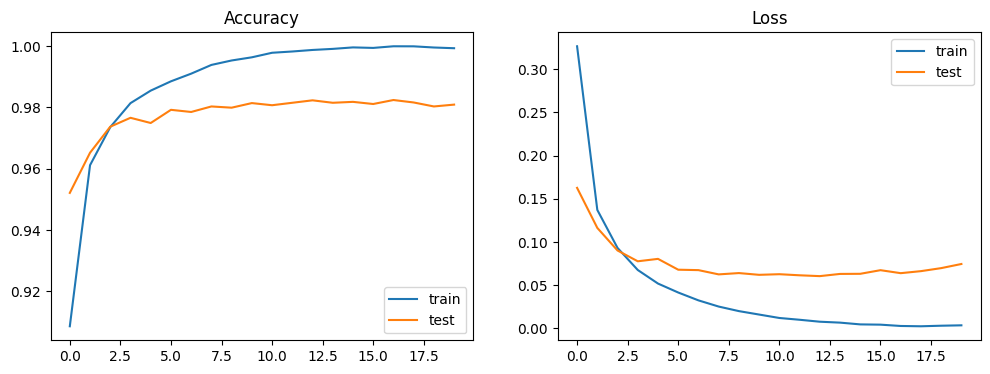

In [ ]:
model = ffnn_one_HL(X_train.shape[1], 500 ,y_train_oh.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="categorical_crossentropy", metrics=["accuracy"])

start_train = time.time()
history = model.fit(
    X_train, y_train_oh,
    epochs = 20,
    batch_size = 250,
    verbose = 2,
    validation_data=(X_test, y_test_oh),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(y_test,np.argmax(pred,axis=1))))

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 397,510 (1.52 MB)

 Trainable params: 397,510 (1.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
120/120 - 2s - 16ms/step - accuracy: 0.9209 - loss: 0.2559 - val_accuracy: 0.9651 - val_loss: 0.1112
Epoch 2/30
120/120 - 0s - 3ms/step - accuracy: 0.9734 - loss: 0.0858 - val_accuracy: 0.9727 - val_loss: 0.0838
Epoch 3/30
120/120 - 0s - 3ms/step - accuracy: 0.9812 - loss: 0.0587 - val_accuracy: 0.9702 - val_loss: 0.0935
Epoch 4/30
120/120 - 0s - 3ms/step - accuracy: 0.9851 - loss: 0.0446 - val_accuracy: 0.9783 - val_loss: 0.0697
Epoch 5/30
120/120 - 0s - 3ms/step - accuracy: 0.9883 - loss: 0.0356 - val_accuracy: 0.9788 - val_loss: 0.0733
Epoch 6/30
120/120 - 0s - 3ms/step - accuracy: 0.9905 - loss: 0.0280 - val_accuracy: 0.9795 - val_loss: 0.0740
Epoch 7/30
120/120 - 0s - 3ms/step - accuracy: 0.9911 - loss: 0.0263 - val_accuracy: 0.9794 - val_loss: 0.0780
Epoch 8/30
120/120 - 0s - 3ms/step - accuracy: 0.9924 - loss: 0.0211 - val_accuracy: 0.9746 - val_loss: 0.0989
Epoch 9/30
120/120 - 0s - 3ms/step - accuracy: 0.9922 - loss: 0.0224 - val_accuracy: 0.9763 - val_loss: 0.0956


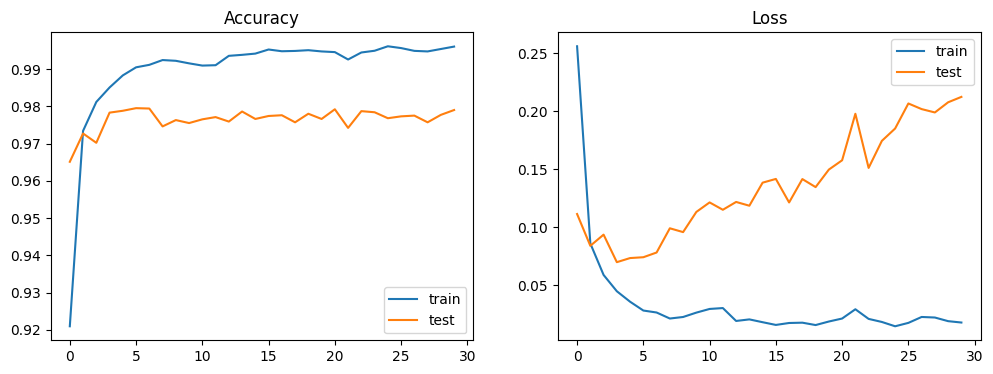

In [ ]:
model = ffnn_one_HL(X_train.shape[1], 500 ,y_train_oh.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss="categorical_crossentropy", metrics=["accuracy"])

start_train = time.time()
history = model.fit(
    X_train, y_train_oh,
    epochs = 30,
    batch_size = 500,
    verbose = 2,
    validation_data=(X_test, y_test_oh),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(y_test,np.argmax(pred,axis=1))))

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 397,510 (1.52 MB)

 Trainable params: 397,510 (1.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
120/120 - 2s - 16ms/step - accuracy: 0.8888 - loss: 0.4124 - val_accuracy: 0.9383 - val_loss: 0.2140
Epoch 2/30
120/120 - 0s - 3ms/step - accuracy: 0.9502 - loss: 0.1767 - val_accuracy: 0.9586 - val_loss: 0.1456
Epoch 3/30
120/120 - 0s - 3ms/step - accuracy: 0.9653 - loss: 0.1230 - val_accuracy: 0.9662 - val_loss: 0.1109
Epoch 4/30
120/120 - 0s - 3ms/step - accuracy: 0.9738 - loss: 0.0930 - val_accuracy: 0.9707 - val_loss: 0.0985
Epoch 5/30
120/120 - 0s - 3ms/step - accuracy: 0.9793 - loss: 0.0743 - val_accuracy: 0.9745 - val_loss: 0.0812
Epoch 6/30
120/120 - 0s - 3ms/step - accuracy: 0.9837 - loss: 0.0589 - val_accuracy: 0.9774 - val_loss: 0.0755
Epoch 7/30
120/120 - 0s - 3ms/step - accuracy: 0.9869 - loss: 0.0492 - val_accuracy: 0.9771 - val_loss: 0.0734
Epoch 8/30
120/120 - 0s - 3ms/step - accuracy: 0.9892 - loss: 0.0407 - val_accuracy: 0.9768 - val_loss: 0.0703
Epoch 9/30
120/120 - 0s - 3ms/step - accuracy: 0.9912 - loss: 0.0342 - val_accuracy: 0.9797 - val_loss: 0.0655


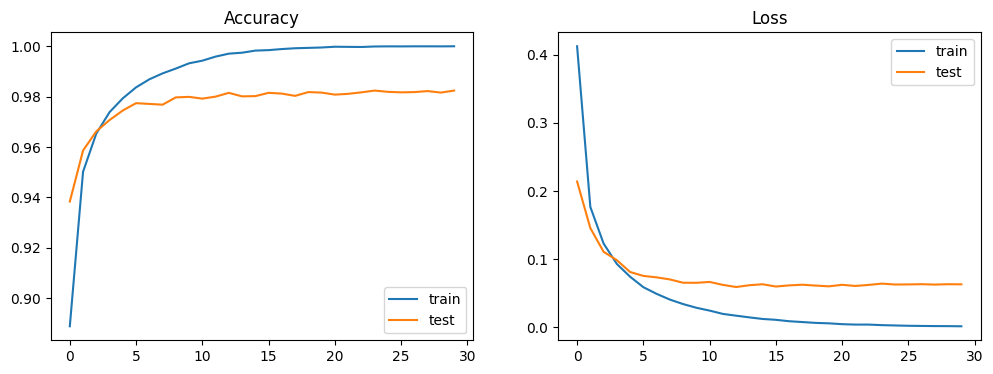

In [ ]:
model = ffnn_one_HL(X_train.shape[1], 500 ,y_train_oh.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="categorical_crossentropy", metrics=["accuracy"])

start_train = time.time()
history = model.fit(
    X_train, y_train_oh,
    epochs = 30,
    batch_size = 500,
    verbose = 2,
    validation_data=(X_test, y_test_oh),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(y_test,np.argmax(pred,axis=1))))

The one-hidden-layer FFNN performs best with moderate batch size (250) and a lower learning rate (0.001) trained for 10 epochs, achieving a balance between convergence speed, stability, and generalization.

## Feature-Order Sensitivity

Suppose we randomly shuffle the columns in the dataset. Does this make the problem more difficult for a person? Do you expect this will make the problem more difficult for a dense neural network?

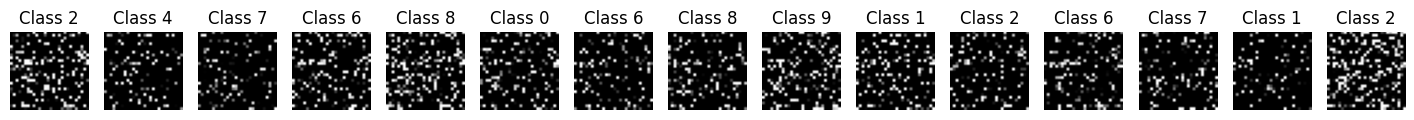

In [ ]:
ind = np.random.permutation(X_train.shape[1])
X_train = X_train[:,ind]
X_test = X_test[:,ind]
fig, ax = plt.subplots(ncols=nimgs, figsize=(18,4))
for i, s in enumerate(sel):
  ax[i].imshow(X_train[s].reshape(28,28),cmap='gray')
  ax[i].set_title(f'Class {y_train[s]}')
  ax[i].set_axis_off()
plt.show()

Evaluate the performance of the neural network with one hidden layer on this modified dataset and compare it with the performance on the original dataset. Does the result match your expectations?

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_50 (Dense)                │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 397,510 (1.52 MB)

 Trainable params: 397,510 (1.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
120/120 - 2s - 16ms/step - accuracy: 0.9098 - loss: 0.3051 - val_accuracy: 0.9634 - val_loss: 0.1201
Epoch 2/20
120/120 - 0s - 3ms/step - accuracy: 0.9710 - loss: 0.0944 - val_accuracy: 0.9749 - val_loss: 0.0861
Epoch 3/20
120/120 - 0s - 3ms/step - accuracy: 0.9805 - loss: 0.0622 - val_accuracy: 0.9747 - val_loss: 0.0822
Epoch 4/20
120/120 - 0s - 3ms/step - accuracy: 0.9865 - loss: 0.0432 - val_accuracy: 0.9793 - val_loss: 0.0666
Epoch 5/20
120/120 - 0s - 3ms/step - accuracy: 0.9887 - loss: 0.0338 - val_accuracy: 0.9773 - val_loss: 0.0799
Epoch 6/20
120/120 - 0s - 3ms/step - accuracy: 0.9913 - loss: 0.0266 - val_accuracy: 0.9747 - val_loss: 0.0929
Epoch 7/20
120/120 - 0s - 3ms/step - accuracy: 0.9919 - loss: 0.0246 - val_accuracy: 0.9775 - val_loss: 0.0909
Epoch 8/20
120/120 - 0s - 3ms/step - accuracy: 0.9928 - loss: 0.0210 - val_accuracy: 0.9802 - val_loss: 0.0778
Epoch 9/20
120/120 - 0s - 3ms/step - accuracy: 0.9953 - loss: 0.0156 - val_accuracy: 0.9772 - val_loss: 0.0983


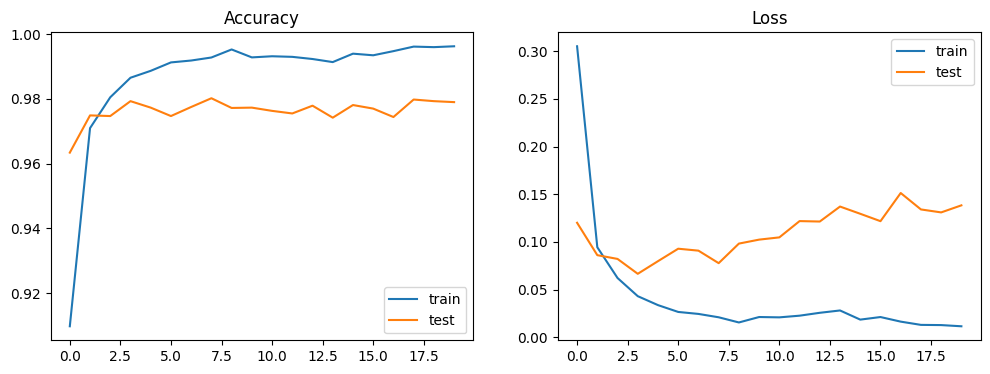

In [ ]:
model = ffnn_one_HL(X_train.shape[1], 500 ,y_train_oh.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss="categorical_crossentropy", metrics=["accuracy"])

start_train = time.time()
history = model.fit(
    X_train, y_train_oh,
    epochs = 20,
    batch_size = 500,
    verbose = 2,
    validation_data=(X_test, y_test_oh),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(y_test,np.argmax(pred,axis=1))))

Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_52 (Dense)                │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 397,510 (1.52 MB)

 Trainable params: 397,510 (1.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
120/120 - 2s - 16ms/step - accuracy: 0.8900 - loss: 0.4089 - val_accuracy: 0.9397 - val_loss: 0.2071
Epoch 2/20
120/120 - 0s - 3ms/step - accuracy: 0.9518 - loss: 0.1721 - val_accuracy: 0.9601 - val_loss: 0.1396
Epoch 3/20
120/120 - 0s - 3ms/step - accuracy: 0.9660 - loss: 0.1213 - val_accuracy: 0.9667 - val_loss: 0.1158
Epoch 4/20
120/120 - 0s - 3ms/step - accuracy: 0.9737 - loss: 0.0935 - val_accuracy: 0.9713 - val_loss: 0.0936
Epoch 5/20
120/120 - 0s - 3ms/step - accuracy: 0.9801 - loss: 0.0720 - val_accuracy: 0.9744 - val_loss: 0.0875
Epoch 6/20
120/120 - 0s - 3ms/step - accuracy: 0.9844 - loss: 0.0580 - val_accuracy: 0.9778 - val_loss: 0.0775
Epoch 7/20
120/120 - 0s - 3ms/step - accuracy: 0.9873 - loss: 0.0485 - val_accuracy: 0.9775 - val_loss: 0.0747
Epoch 8/20
120/120 - 0s - 3ms/step - accuracy: 0.9891 - loss: 0.0398 - val_accuracy: 0.9787 - val_loss: 0.0689
Epoch 9/20
120/120 - 0s - 3ms/step - accuracy: 0.9912 - loss: 0.0338 - val_accuracy: 0.9799 - val_loss: 0.0650


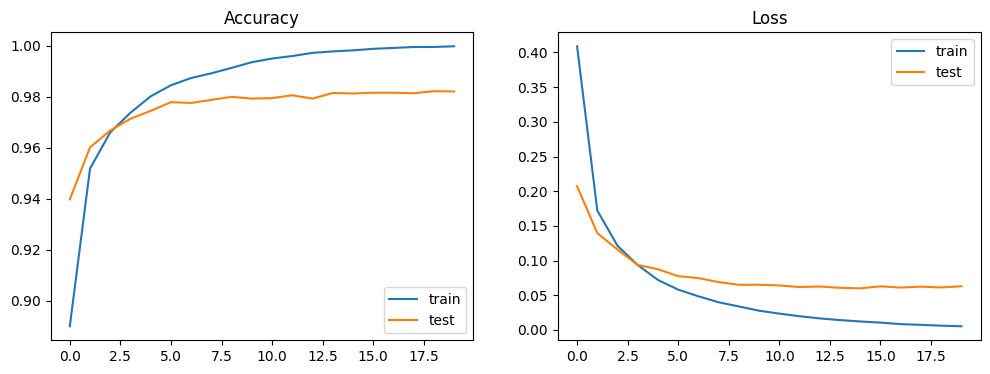

In [ ]:
model = ffnn_one_HL(X_train.shape[1], 500 ,y_train_oh.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="categorical_crossentropy", metrics=["accuracy"])

start_train = time.time()
history = model.fit(
    X_train, y_train_oh,
    epochs = 20,
    batch_size = 500,
    verbose = 2,
    validation_data=(X_test, y_test_oh),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(y_test,np.argmax(pred,axis=1))))

Model: "sequential_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_54 (Dense)                │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 397,510 (1.52 MB)

 Trainable params: 397,510 (1.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
60/60 - 2s - 35ms/step - accuracy: 0.8525 - loss: 0.5611 - val_accuracy: 0.9279 - val_loss: 0.2619
Epoch 2/20
60/60 - 0s - 4ms/step - accuracy: 0.9365 - loss: 0.2292 - val_accuracy: 0.9464 - val_loss: 0.1933
Epoch 3/20
60/60 - 0s - 4ms/step - accuracy: 0.9522 - loss: 0.1712 - val_accuracy: 0.9572 - val_loss: 0.1515
Epoch 4/20
60/60 - 0s - 4ms/step - accuracy: 0.9618 - loss: 0.1356 - val_accuracy: 0.9623 - val_loss: 0.1283
Epoch 5/20
60/60 - 0s - 4ms/step - accuracy: 0.9692 - loss: 0.1107 - val_accuracy: 0.9679 - val_loss: 0.1093
Epoch 6/20
60/60 - 0s - 4ms/step - accuracy: 0.9744 - loss: 0.0942 - val_accuracy: 0.9709 - val_loss: 0.0988
Epoch 7/20
60/60 - 0s - 4ms/step - accuracy: 0.9778 - loss: 0.0799 - val_accuracy: 0.9721 - val_loss: 0.0908
Epoch 8/20
60/60 - 0s - 4ms/step - accuracy: 0.9815 - loss: 0.0682 - val_accuracy: 0.9743 - val_loss: 0.0845
Epoch 9/20
60/60 - 0s - 4ms/step - accuracy: 0.9843 - loss: 0.0597 - val_accuracy: 0.9754 - val_loss: 0.0816
Epoch 10/20
60/60 

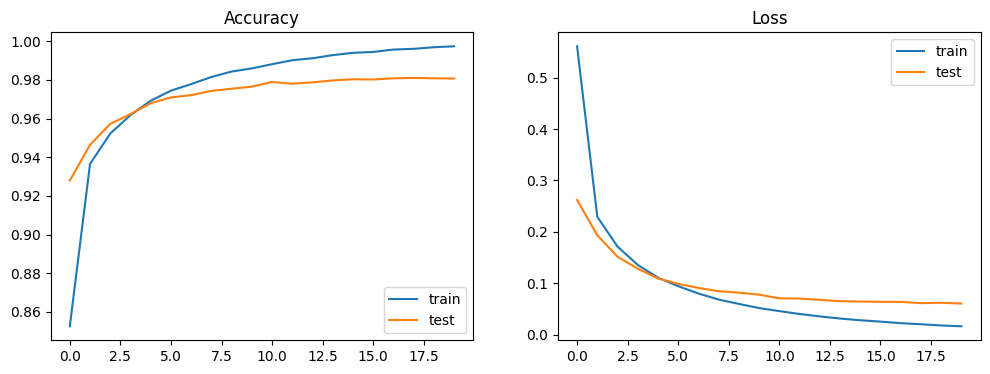

In [ ]:
model = ffnn_one_HL(X_train.shape[1], 500 ,y_train_oh.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="categorical_crossentropy", metrics=["accuracy"])

start_train = time.time()
history = model.fit(
    X_train, y_train_oh,
    epochs = 20,
    batch_size = 1000,
    verbose = 2,
    validation_data=(X_test, y_test_oh),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(y_test,np.argmax(pred,axis=1))))

Shuffling columns makes the task drastically harder for humans but does not significantly affect a dense neural network’s performance. However, this is not the case for architectures like convolutional neural networks (CNNs), which explicitly depend on spatial relationships. For CNNs, shuffling destroys the locality structure, making the task much more difficult.